In [1]:
import os
import glob
import sys


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb  # Has to be imported first to avoid conflicts with PyROOT
import json
from time import time
from datetime import timedelta
from yaml import safe_load, YAMLError, dump
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier
from scipy.interpolate import RectBivariateSpline
from scipy import optimize


import config as cfg 
import efficiency_finder
#import variable_plotter as vp
plt.style.use('fcc.mplstyle')

In [2]:
# Function to load the BDT model from a JSON file
def load_bdt_model(json_path):
    bdt_model = xgb.Booster()
    bdt_model.load_model(json_path)
    return bdt_model

# Function to load the BDT model from a JSON file
def load_bdt_model_sklearn(json_path):
    bdt_model = XGBClassifier()
    bdt_model.load_model(json_path)
    return bdt_model

# Return list of variables to use in the bdt as a python list
def vars_fromyaml(path, bdtlist):
    with open(path) as stream:
        try:
            file = safe_load(stream)
            bdtvars = file[bdtlist]
        except YAMLError as exc:
            print(exc)
    return bdtvars

def load_bdt_and_apply(pickled_df_fname = "bdt-lh_dataframe.pkl", 
                        config_bdtopts = cfg.baseline_bdt_lh_opts,
                        training_round = "multiclass_baseline",
                        hps_dict_name = "default-hps",
                        features_list_name = "bdth-plus-vars",
                        bdt_label = '_lh'
                        ): # hps dict and features_list_name specift BDT used
    
    
    #path to data and outputs
    outputpath   = config_bdtopts['outputPath']
    yamlpath = cfg.fccana_opts['yamlPath']

    #Getting BDT vars for training from yaml
    bdtvars      = vars_fromyaml(yamlpath, features_list_name)
    bdtname      = f'BDT{bdt_label}_{hps_dict_name}_{features_list_name}'

    #path to pickled data
    pickled_df_path = os.path.join(outputpath, pickled_df_fname)

    #path to saved bdt
    bdt_json_path = os.path.join(outputpath,training_round,f"{bdtname}.json")

    # Load the BDT model
    try:
        print("Loading BDT model...")
        bdt_model = load_bdt_model_sklearn(bdt_json_path)
        print("BDT model loaded successfully.")
    except Exception as e:
        print(f"Error loading BDT model: {e}")
        quit()

    # Read df saved to pickle and add BDT 

    #Getting BDT vars for training from yaml
    # load pickled df
    df = pd.read_pickle(pickled_df_path)

    #add bdt score
    class_names = bdt_model.classes_
    probabilities = bdt_model.predict_proba(df[bdtvars])
    for i in range(probabilities.shape[1]):
        df[f'bdt_score_{class_names[i]}'] = probabilities[:, i]


    return bdt_model, bdtname, df

In [3]:
baseline_model, baseline_bdtname, baseline_dataframe = load_bdt_and_apply( pickled_df_fname = "bdt_lh_dataframe.pkl", 
                        config_bdtopts = cfg.baseline_bdt_lh_opts,
                        training_round = "multiclass_baseline",
                        hps_dict_name = "default-hps",
                        features_list_name = "bdth-plus-vars",
                        bdt_label = '_lh')

Loading BDT model...
BDT model loaded successfully.


In [4]:
baseline_df = baseline_dataframe[baseline_dataframe["sample"]!=0] #ie. not training data

In [5]:
ot_model, ot_bdtname, ot_dataframe = load_bdt_and_apply( pickled_df_fname = "bdt_lh_dataframe.pkl", 
                        config_bdtopts = cfg.optimised_bdt_lh_opts,
                        training_round = "optimised_hps_overtrained",
                        hps_dict_name = "multiclass-optimum",
                        features_list_name = "bdth-plus-vars",
                        bdt_label = '_lh')

Loading BDT model...
BDT model loaded successfully.


In [6]:
ot_df = ot_dataframe[ot_dataframe["sample"]!=0] #ie. not training data

In [7]:
model, bdtname, dataframe = load_bdt_and_apply( pickled_df_fname = "bdt_lh_dataframe.pkl", 
                        config_bdtopts = cfg.optimised_bdt_lh_opts,
                        training_round = "adjusted_optimised_hps_small_overtraining",
                        hps_dict_name = "multiclass-optimum",
                        features_list_name = "bdtlh-vars-v1",
                        bdt_label = '_lh')

Loading BDT model...
BDT model loaded successfully.


In [8]:
df = dataframe[dataframe["sample"]!=0] #ie. not training data

In [9]:
hpp_model, hpp_bdtname, hpp_dataframe = load_bdt_and_apply( pickled_df_fname = "bdt_lh_dataframe.pkl", 
                        config_bdtopts = cfg.optimised_bdt_lh_opts,
                        training_round = "default-plus-hps",
                        hps_dict_name = "default-plus-hps",
                        features_list_name = "bdtlh-vars-v1",
                        bdt_label = '_lh')

hpp_df = hpp_dataframe[hpp_dataframe["sample"]!=0] #ie. not training data

Loading BDT model...
BDT model loaded successfully.


In [10]:
prelim_cut_eff_dict = cfg.prelim_cut_effs

In [24]:
# optimise cut to maximise S/sqrt(S+B) for 1e-7 BF - see what S/sqrt(S+B) is for different models)
#currently just considering Bs
def make_interpolated_eff_map(df,lrange=(0.9,1) ,hrange=(0.9,1)): #df needs to be just test and validation here to combat effect of having overtrained on training

    lsearch = np.linspace(*lrange,150) 
    hsearch = np.linspace(*hrange,150)
    
    #define lists need etc
    eff_dict={}
    interp_eff_dict={}
    N_dict={}
    eff_df=np.zeros((len(lsearch), len(hsearch)))

    print('Creating efficiency map for decay:')
    for decay in df["decay"].unique():
        if decay =='p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu':
            continue
        print(decay)
        
        eff_df=np.zeros((len(lsearch), len(hsearch)))
        subf = df[df["decay"]==decay]
        l_arr=[]
        h_arr=[]

        #record initial N for binomial error
        N_dict[decay] = len(subf)
    
        for l in np.arange(0,len(lsearch),1):
            for h in np.arange(0,len(hsearch),1):
                l_arr.append(lsearch[l])
                h_arr.append(hsearch[h])
    
                cutdf = subf[((1-subf["bdt_score_1"])>hsearch[h])&((1-subf["bdt_score_0"])>lsearch[l])]
                eff_lh = len(cutdf)/len(subf)
                eff_df[l,h] = eff_lh    
    
        eff_dict[f"{decay}"] = eff_df

        interp_eff = RectBivariateSpline(lsearch, hsearch, eff_df, s=0.000005)
        interp_eff_dict[f"{decay}"] = interp_eff

    return eff_dict, interp_eff_dict, N_dict


def make_eff_plots(eff_dict, interp_eff_dict,N_dict,lrange=(0.9,1) ,hrange=(0.9,1) ):
    lsearch = np.linspace(*lrange,150) 
    hsearch = np.linspace(*hrange,150)

    for decay in interp_eff_dict.keys():
        lsearchinterp = np.linspace(*lrange,1000) 
        hsearchinterp = np.linspace(*hrange,1000)

        # also calculate error using binomial error formula
        # error = 1/Nsqrt[EN(1-E)] for initial number N pre cut and estimated eff E
        #https://lss.fnal.gov/archive/test-tm/2000/fermilab-tm-2286-cd.pdf
        splined=np.zeros((len(lsearch), len(hsearch)))
        pull=np.zeros((len(lsearch), len(hsearch)))
        N = N_dict[decay]
        E = eff_dict[decay]
        error = 1/N *(np.sqrt(E*N*(1-E)))
        for l in np.arange(0,len(lsearch),1):
            for h in np.arange(0,len(hsearch),1):
                splined[l,h] = interp_eff_dict[f"{decay}"](lsearch[l],hsearch[h],grid=False)
                if error[l,h]>0:
                    pull[l,h] = (E[l,h] - splined[l,h])/error[l,h]
                else:
                    pull[l,h]=0
        
        n = 140
        '''
        plt.figure()
        plt.plot(hsearch,eff_dict[f"{decay}"][n,:], label=r'efficiency slice at 1-P(light) $>$'+ f'{lsearch[n]}')
        plt.plot(hsearchinterp,interp_eff_dict[f"{decay}"](lsearch[n],hsearchinterp,grid=False), label=r'interpolated efficiency slice a 1-P(light) $>$'+ f'{lsearch[n]}')
        plt.xlabel('BDT_lh 1-P(heavy)')
        plt.ylabel(f'{decay} efficiency')
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(lsearch,eff_dict[f"{decay}"][:,n], label=r'efficiency slice at 1-P(heavy) $>$'+ f'{hsearch[n]}')
        plt.plot(lsearchinterp,interp_eff_dict[f"{decay}"](lsearchinterp,hsearch[n],grid=False), label=r'interpolated efficiency slice a 1-P(heavy) $>$'+ f'{hsearch[n]}')
        plt.xlabel('BDT_lh 1-P(light)')
        plt.ylabel(f'{decay} efficiency')
        plt.legend()
        plt.show()
        '''
        fig, ax = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3,1]}, figsize=(6,6))
        #ax[0].plot(hsearch,eff_dict[f"{decay}"][n,:], label=r'efficiency slice at 1-P(light) $>$'+ f'{lsearch[n]}',color='b')
        ax[0].errorbar(hsearch[::3],eff_dict[f"{decay}"][n,::3],error[n,::3],label=r'efficiency slice at 1-P(light) $>$'+ f'{lsearch[n]}')
        ax[0].errorbar(hsearchinterp,interp_eff_dict[f"{decay}"](lsearch[n],hsearchinterp,grid=False), label=r'interpolated efficiency slice a 1-P(light) $>$'+ f'{lsearch[n]}')
       
        ax[1].errorbar( hsearch[::3], pull[n,::3], np.ones_like(pull[n,::3]) )
        ax[1].axhline(0, c='k', ls='--' )   
        ax[1].set_ylabel('Pull')
        ax[1].set_ylim(-3,3)
        ax[0].set_xlabel('BDT_lh 1-P(heavy)')
        ax[0].set_ylabel(f'{decay} efficiency')
        ax[0].legend()
        fig.tight_layout()
        
        fig, ax = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3,1]}, figsize=(6,6))
        #ax[0].plot(lsearch,eff_dict[f"{decay}"][:,n], label=r'efficiency slice at 1-P(heavy) $>$'+ f'{hsearch[n]}',color='b')
        ax[0].errorbar(lsearch[::3],eff_dict[f"{decay}"][::3,n],error[::3,n],label=r'efficiency slice at 1-P(heavy) $>$'+ f'{hsearch[n]}')
        ax[0].errorbar(lsearchinterp,interp_eff_dict[f"{decay}"](lsearchinterp,hsearch[n],grid=False), label=r'interpolated efficiency slice a 1-P(heavy) $>$'+ f'{hsearch[n]}')
       
        ax[1].errorbar( lsearch[::3], pull[::3,n], np.ones_like(pull[::3,n]) )
        ax[1].axhline(0, c='k', ls='--' )   
        ax[1].set_ylabel('Pull')
        ax[1].set_ylim(-3,3)
        ax[0].set_xlabel('BDT_lh 1-P(light)')
        ax[0].set_ylabel(f'{decay} efficiency')
        ax[0].legend()
        fig.tight_layout()



def run_2d_optimisation(interp_eff_dict,lrange_plot=(0.99,1) ,hrange_plot=(0.99,1), nl=1000,nh=1000 ,prelim_eff = prelim_cut_eff_dict, sig_BF=1e-7, plot=  True,vmax=5):
    
    #defining constants needed
    N_z = 6e12
    k = 2* cfg.prod_frac["Bs"] * cfg.branching_fractions["p8_ee_Zbb_ecm91"][0]*N_z*prelim_eff["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu"][0]
    
    sig_eff= interp_eff_dict['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu']

    print('Calculating S and B')

    lsearch = np.linspace(*lrange_plot,nl) 
    hsearch = np.linspace(*hrange_plot,nh)

    S_arr = np.zeros((len(lsearch), len(hsearch)))
    B_arr = np.zeros((len(lsearch), len(hsearch)))
    FOM = np.zeros((len(lsearch), len(hsearch)))
    B_eff_arr = np.zeros((len(lsearch), len(hsearch)))
    
    for l in np.arange(0,len(lsearch), 1):
        for h in np.arange(0,len(hsearch), 1): 
            S = k*sig_BF * sig_eff(lsearch[l],hsearch[h]).item()
            #if l==h and l==0:
                #print(S)
            B = sum([cfg.branching_fractions[s][0]*N_z*prelim_eff[s][0]* interp_eff_dict[s](lsearch[l],hsearch[h]).item() for s in cfg.sample_allocations["hadronic_background"]])
            B_nocut = sum([cfg.branching_fractions[s][0]*N_z*prelim_eff[s][0] for s in cfg.sample_allocations["hadronic_background"]])
            S_arr[l,h]=S
            B_arr[l,h]=B
            if S+B>0:
                FOM[l,h] = S/np.sqrt(S+B)
            else:
                FOM[l,h] = 0
                
            B_eff_arr[l,h]=B/B_nocut


    if plot==True:
        #plot FOM space
        plt.figure()
        plt.imshow(FOM, origin='lower',vmax=vmax)
        plt.xlabel('BDT_lh 1-P(heavy)')
        plt.ylabel('BDT_lh 1-P(light)')
        plt.colorbar(label=r'$S/\sqrt{S+B}$')
        
        # Set tick labels for every 10th bin
        ytick_indices = np.arange(0,len(lsearch), round(len(lsearch)/5))
        xtick_indices = np.arange(0, len(hsearch), round(len(hsearch)/5))
        
        # Use ytick_indices and xtick_indices to set the ticks
        plt.yticks(ytick_indices, [round(lsearch[i],5) for i in ytick_indices])
        plt.xticks(xtick_indices, [round(hsearch[i],5) for i in xtick_indices], rotation=90)
        
        plt.show()


        ## finding maximum so can plot slices
        max_sigma =FOM.max()
        indices = np.unravel_index(np.argmax(FOM), np.shape(FOM))
        l = lsearch[indices[0]]
        h = hsearch[indices[1]]
        
        plt.figure()
        plt.plot(hsearch,FOM[indices[0],:], label=r'FOM slice at optimum cut in 1-P(light) $>$'+f'{round(l,5)}')
        plt.xlabel('BDT_lh 1-P(heavy)')
        plt.ylabel(r'$S/\sqrt{S+B}$')
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(lsearch,FOM[:,indices[1]], label=r'FOM slice at optimum cut in 1-P(heavy) $>$'+f'{round(h,5)}')
        plt.xlabel('BDT_lh 1-P(light)')
        plt.ylabel(r'$S/\sqrt{S+B}$')
        plt.legend()
        plt.show()

        #plot S
        plt.figure()
        plt.plot(lsearch,S_arr[:,indices[1]], label=r'S slice at optimum cut in 1-P(heavy) $>$'+f'{round(h,5)}')
        plt.xlabel('BDT_lh 1-P(light)')
        plt.ylabel(r'S')
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(hsearch,S_arr[indices[0],:], label=r'S slice at optimum cut in 1-P(light) $>$'+f'{round(l,5)}')
        plt.xlabel('BDT_lh 1-P(heavy)')
        plt.ylabel(r'S')
        plt.legend()
        plt.show()
        
        #plot B
        plt.figure()
        plt.plot(lsearch,B_arr[:,indices[1]], label=r'B slice at optimum cut in 1-P(heavy) $>$'+f'{round(h,5)}')
        plt.xlabel('BDT_lh 1-P(light)')
        plt.ylabel(r'B')
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(hsearch,B_arr[indices[0],:], label=r'B slice at optimum cut in 1-P(light) $>$'+f'{round(l,5)}')
        plt.xlabel('BDT_lh 1-P(heavy)')
        plt.ylabel(r'B')
        plt.legend()
        plt.show()

    return FOM, S_arr, B_arr, B_eff_arr, lsearch, hsearch, sig_BF


def run_2d_optimisation_no_interpolation(eff_dict,lrange=(0.9,1) ,hrange=(0.9,1) ,prelim_eff = prelim_cut_eff_dict, sig_BF=1e-7, plot=  True,vmax=5):
    
    #defining constants needed
    N_z = 6e12
    k = 2* cfg.prod_frac["Bs"] * cfg.branching_fractions["p8_ee_Zbb_ecm91"][0]*N_z*prelim_eff["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu"][0]
    
    sig_eff= eff_dict['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu']

    print('Calculating S and B')

    lsearch = np.linspace(*lrange,150) 
    hsearch = np.linspace(*hrange,150)

    S_arr = np.zeros((len(lsearch), len(hsearch)))
    B_arr = np.zeros((len(lsearch), len(hsearch)))
    FOM = np.zeros((len(lsearch), len(hsearch)))
    B_eff_arr = np.zeros((len(lsearch), len(hsearch)))
    
    for l in np.arange(0,len(lsearch), 1):
        for h in np.arange(0,len(hsearch), 1): 
            S = k*sig_BF * sig_eff[l,h]
            #if l==h and l==0:
                #print(S)
            B = sum([cfg.branching_fractions[s][0]*N_z*prelim_eff[s][0]* eff_dict[s][l,h] for s in cfg.sample_allocations["hadronic_background"]])
            B_nocut = sum([cfg.branching_fractions[s][0]*N_z*prelim_eff[s][0] for s in cfg.sample_allocations["hadronic_background"]])
            S_arr[l,h]=S
            B_arr[l,h]=B
            if S+B>0:
                FOM[l,h] = S/np.sqrt(S+B)
            else:
                FOM[l,h] = 0

            B_eff_arr[l,h]=B/B_nocut


    if plot==True:
        #plot FOM space
        plt.figure()
        plt.imshow(FOM, origin='lower',vmax=vmax)
        plt.xlabel('BDT_lh 1-P(heavy)')
        plt.ylabel('BDT_lh 1-P(light)')
        plt.colorbar(label=r'$S/\sqrt{S+B}$')
        
        # Set tick labels for every 10th bin
        ytick_indices = np.arange(0,len(lsearch), round(len(lsearch)/5))
        xtick_indices = np.arange(0, len(hsearch), round(len(hsearch)/5))
        
        # Use ytick_indices and xtick_indices to set the ticks
        plt.yticks(ytick_indices, [round(lsearch[i],5) for i in ytick_indices])
        plt.xticks(xtick_indices, [round(hsearch[i],5) for i in xtick_indices], rotation=90)
        
        plt.show()
        
        ## finding maximum so can plot slices
        max_sigma =FOM.max()
        indices = np.unravel_index(np.argmax(FOM), np.shape(FOM))
        l = lsearch[indices[0]]
        h = hsearch[indices[1]]
        
        plt.figure()
        plt.plot(hsearch,FOM[indices[0],:], label=r'FOM slice at optimum cut in 1-P(light) $>$'+f'{round(l,5)}')
        plt.xlabel('BDT_lh 1-P(heavy)')
        plt.ylabel(r'$S/\sqrt{S+B}$')
        plt.legend()
        plt.xlim(0.99,1)
        plt.show()

        plt.figure()
        plt.plot(lsearch,FOM[:,indices[1]], label=r'FOM slice at optimum cut in 1-P(heavy) $>$'+f'{round(h,5)}')
        plt.xlabel('BDT_lh 1-P(light)')
        plt.ylabel(r'$S/\sqrt{S+B}$')
        plt.legend()
        plt.xlim(0.99,1)
        plt.show()

        #plot S
        plt.figure()
        plt.plot(lsearch,S_arr[:,indices[1]], label=r'S slice at optimum cut in 1-P(heavy) $>$'+f'{round(h,5)}')
        plt.xlabel('BDT_lh 1-P(light)')
        plt.ylabel(r'S')
        plt.legend()
        plt.xlim(0.99,1)
        plt.show()

        plt.figure()
        plt.plot(hsearch,S_arr[indices[0],:], label=r'S slice at optimum cut in 1-P(light) $>$'+f'{round(l,5)}')
        plt.xlabel('BDT_lh 1-P(heavy)')
        plt.ylabel(r'S')
        plt.legend()
        plt.xlim(0.99,1)
        plt.show()
        
        #plot B
        plt.figure()
        plt.plot(lsearch,B_arr[:,indices[1]], label=r'B slice at optimum cut in 1-P(heavy) $>$'+f'{round(h,5)}')
        plt.xlabel('BDT_lh 1-P(light)')
        plt.ylabel(r'B')
        plt.legend()
        plt.xlim(0.99,1)
        plt.show()

        plt.figure()
        plt.plot(hsearch,B_arr[indices[0],:], label=r'B slice at optimum cut in 1-P(light) $>$'+f'{round(l,5)}')
        plt.xlabel('BDT_lh 1-P(heavy)')
        plt.ylabel(r'B')
        plt.legend()
        plt.xlim(0.99,1)
        plt.show()

    return FOM, S_arr, B_arr, B_eff_arr, lsearch, hsearch, sig_BF



In [12]:
baseline_eff_dict, baseline_interp_eff_dict, baseline_N_dict = make_interpolated_eff_map(baseline_df,lrange=(0.9,1) ,hrange=(0.9,1))
mid_eff_dict, mid_interp_eff_dict, mid_N_dict = make_interpolated_eff_map(df,lrange=(0.9,1) ,hrange=(0.9,1))
ot_eff_dict, ot_interp_eff_dict, ot_N_dict  = make_interpolated_eff_map(ot_df,lrange=(0.9,1) ,hrange=(0.9,1))
hpp_eff_dict, hpp_interp_eff_dict,  hpp_N_dict = make_interpolated_eff_map(hpp_df,lrange=(0.9,1) ,hrange=(0.9,1))

Creating efficiency map for decay:
p8_ee_Zcc_ecm91
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
p8_ee_Zud_ecm91
p8_ee_Zss_ecm91
p8_ee_Zbb_ecm91
Creating efficiency map for decay:
p8_ee_Zcc_ecm91
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
p8_ee_Zud_ecm91
p8_ee_Zss_ecm91
p8_ee_Zbb_ecm91
Creating efficiency map for decay:
p8_ee_Zcc_ecm91
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
p8_ee_Zud_ecm91
p8_ee_Zss_ecm91
p8_ee_Zbb_ecm91
Creating efficiency map for decay:
p8_ee_Zcc_ecm91
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
p8_ee_Zud_ecm91
p8_ee_Zss_ecm91
p8_ee_Zbb_ecm91


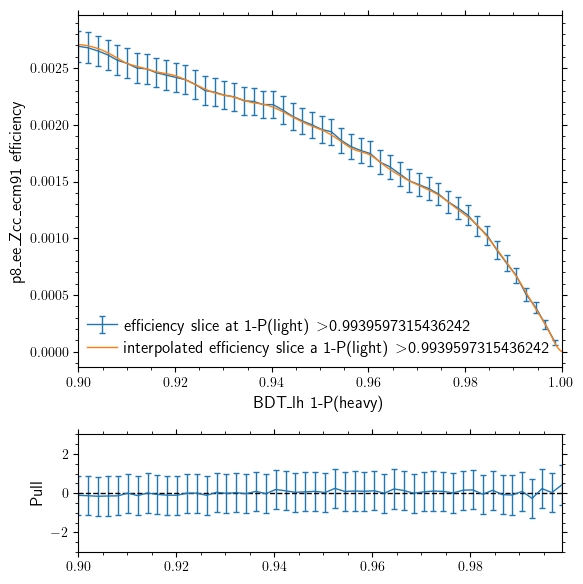

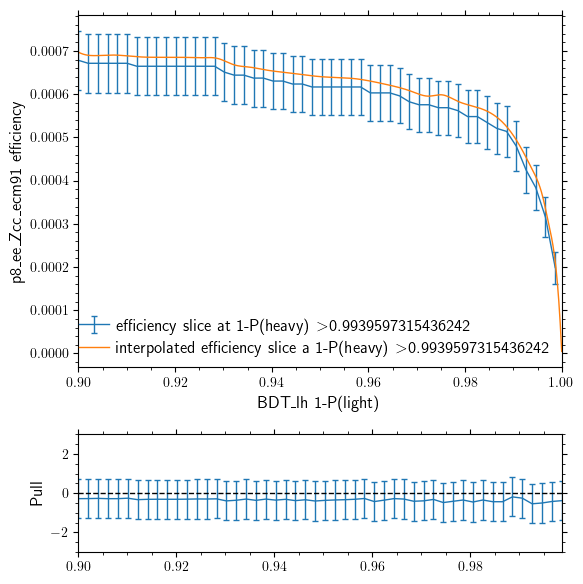

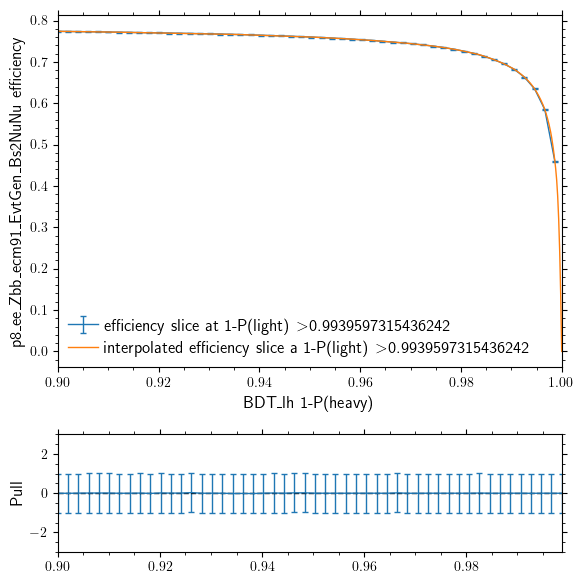

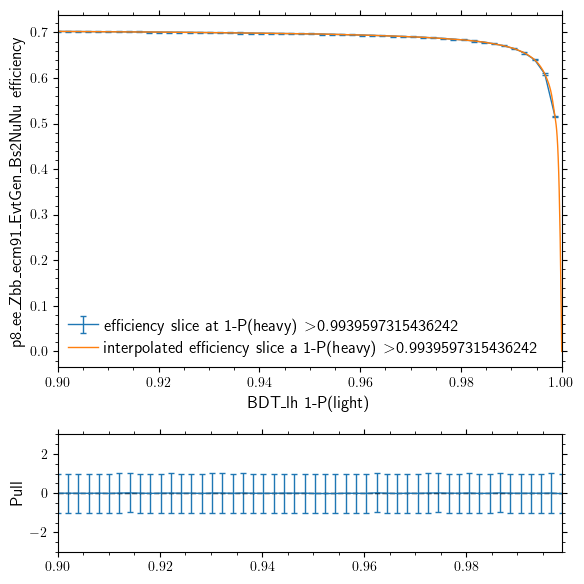

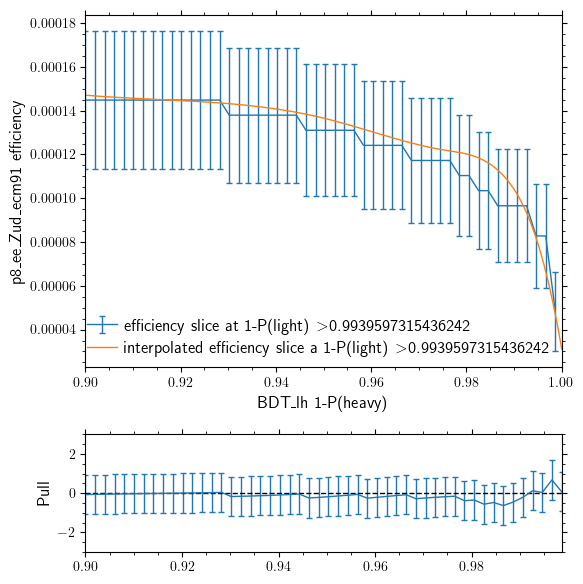

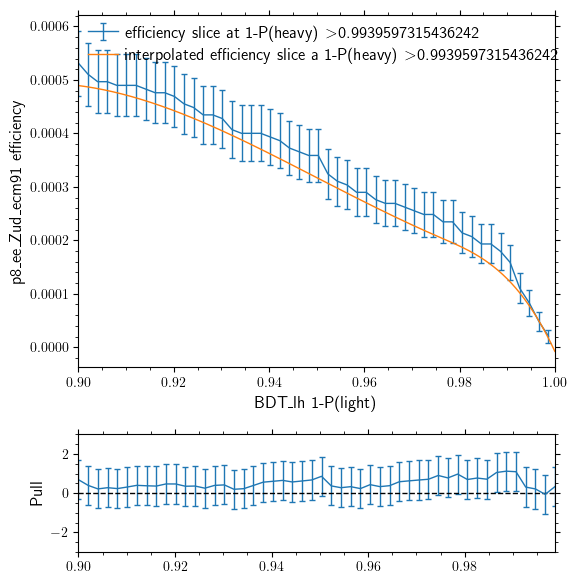

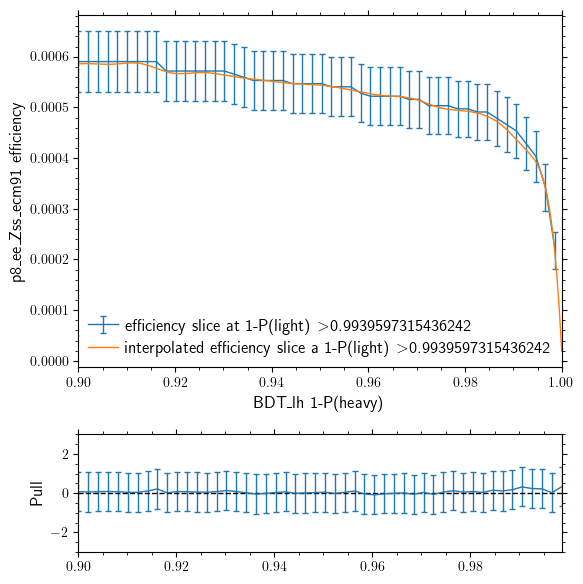

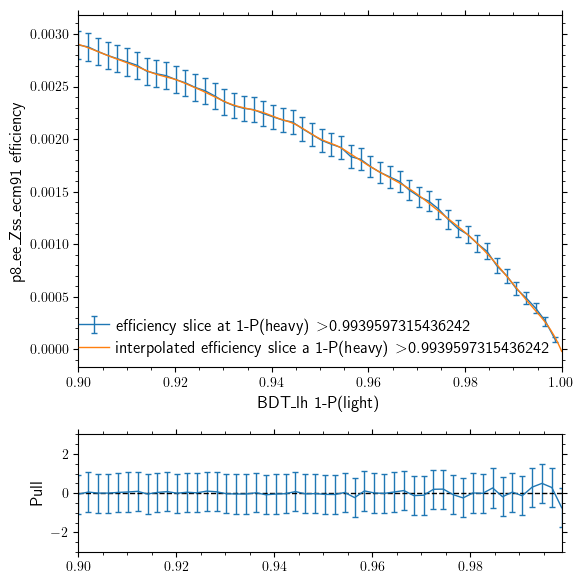

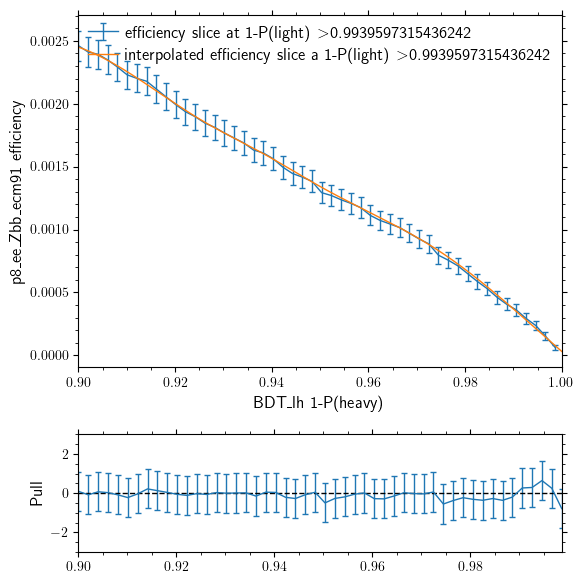

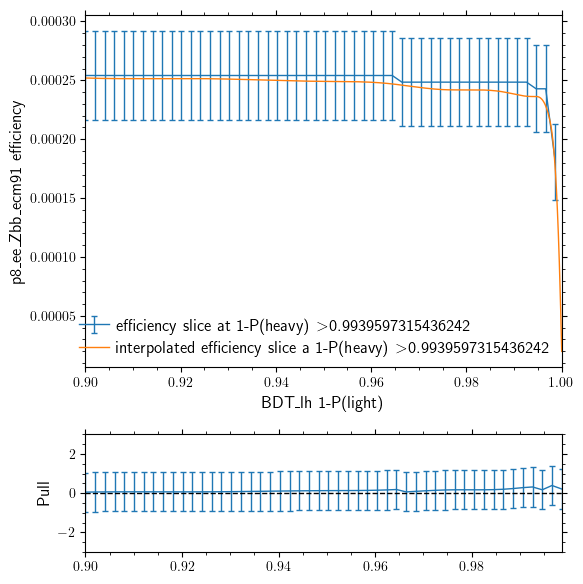

In [13]:
make_eff_plots(baseline_eff_dict, baseline_interp_eff_dict, baseline_N_dict)

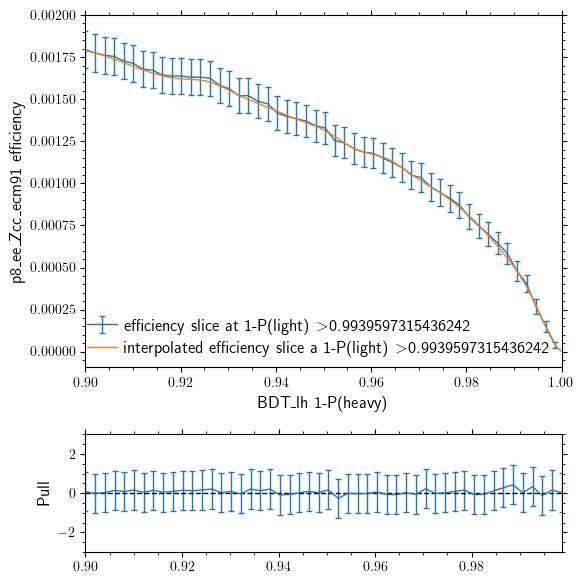

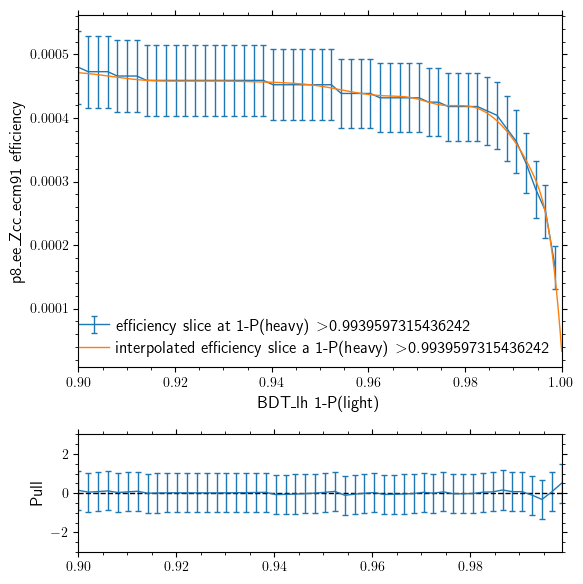

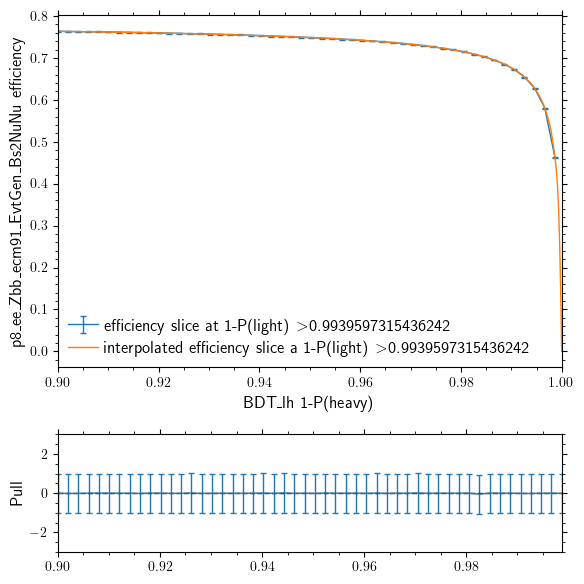

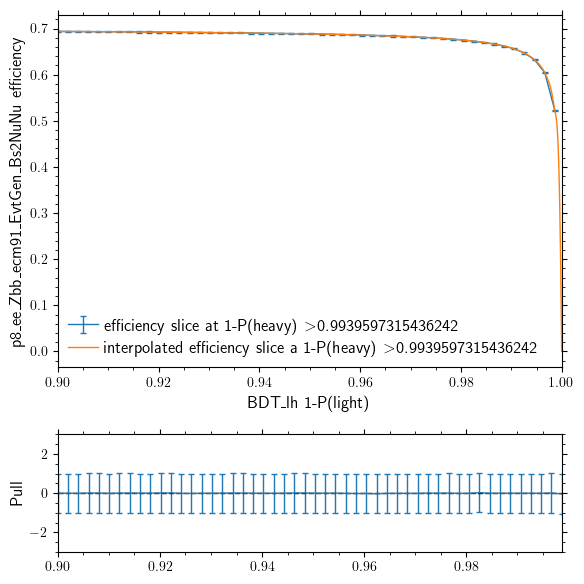

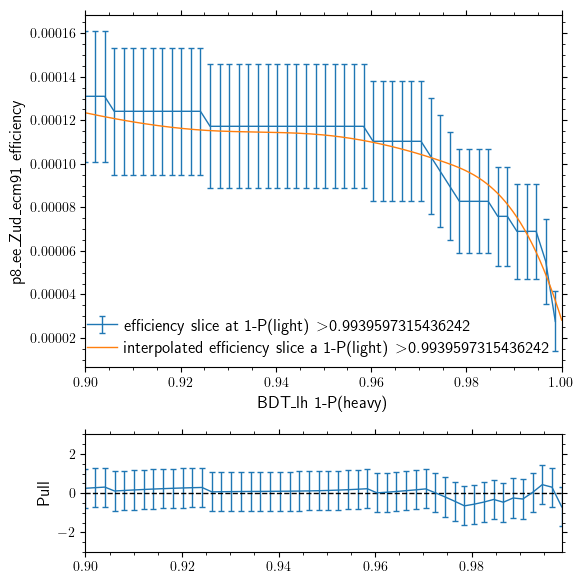

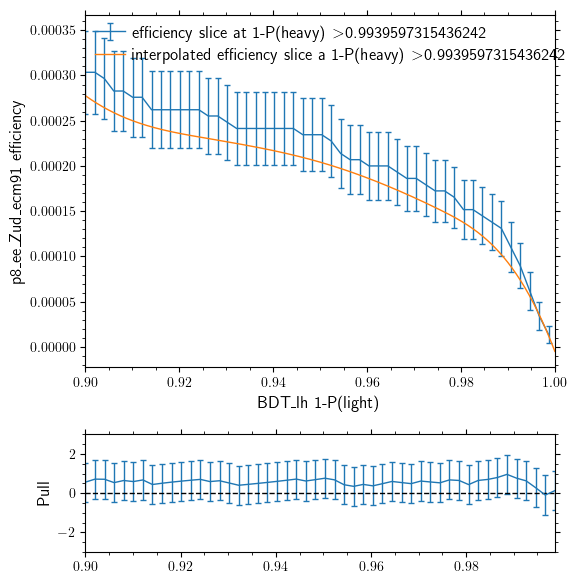

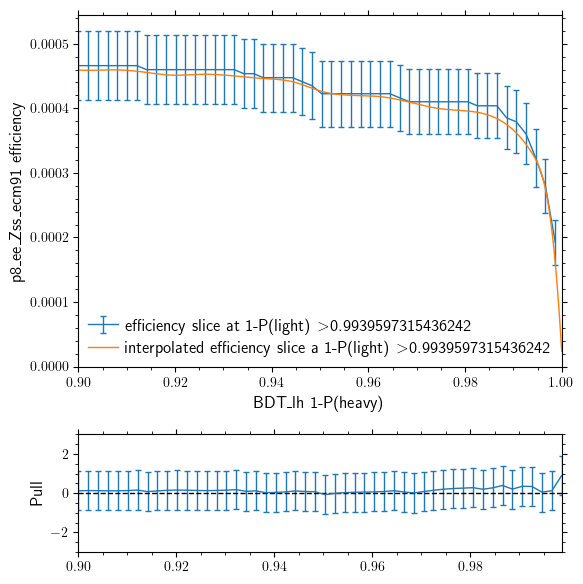

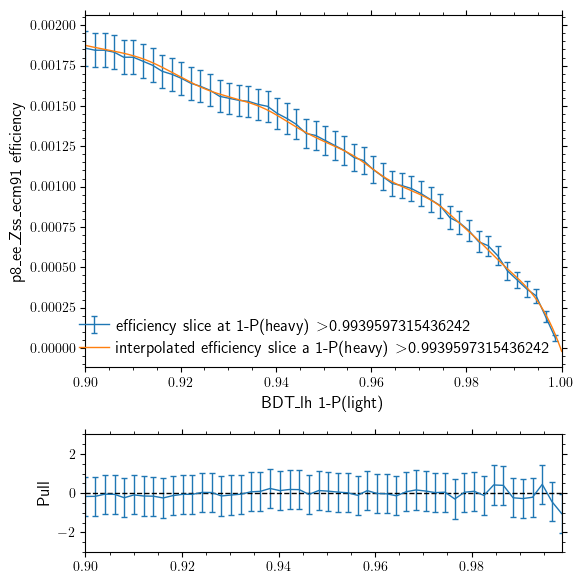

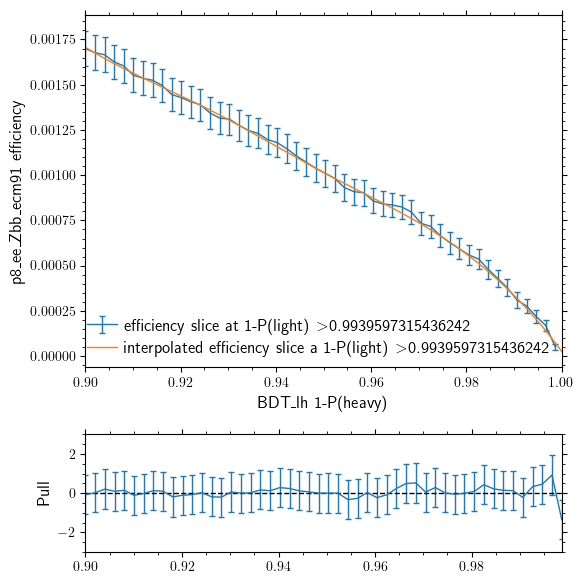

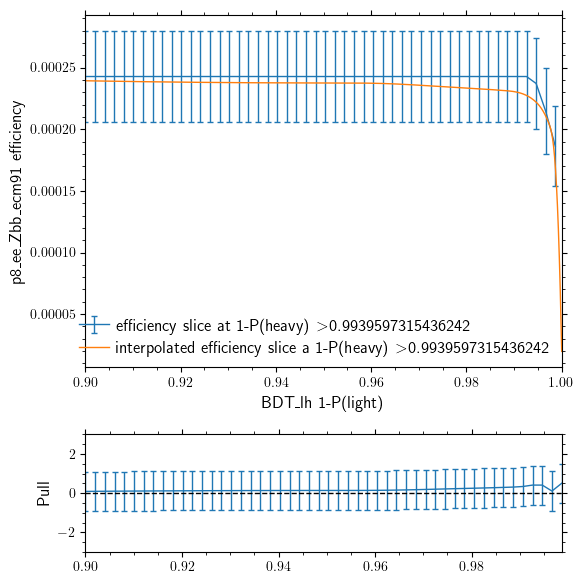

In [14]:
make_eff_plots(hpp_eff_dict, hpp_interp_eff_dict, hpp_N_dict)

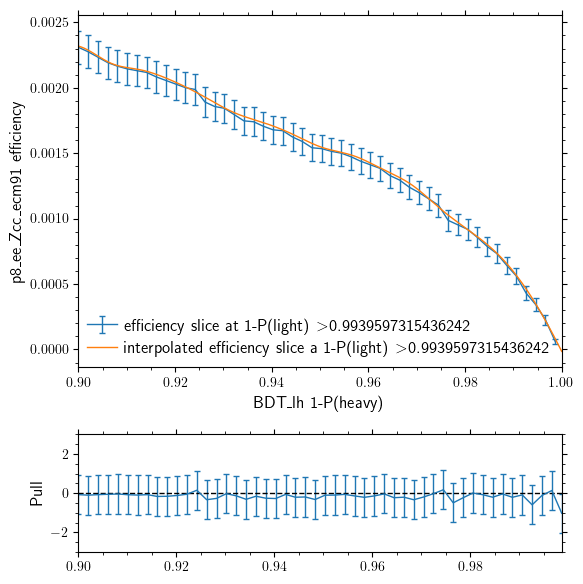

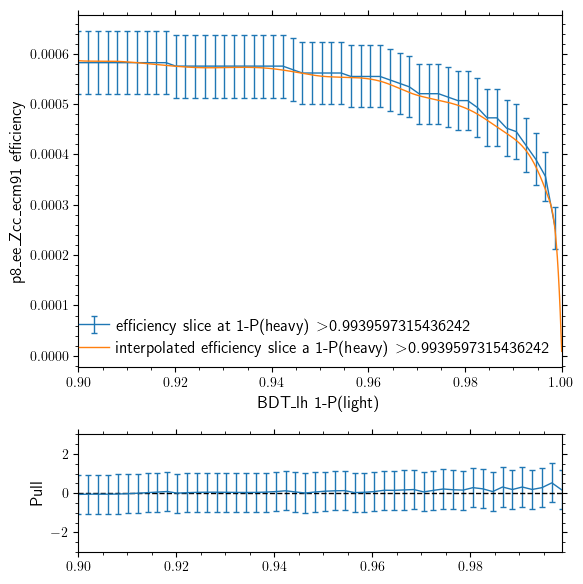

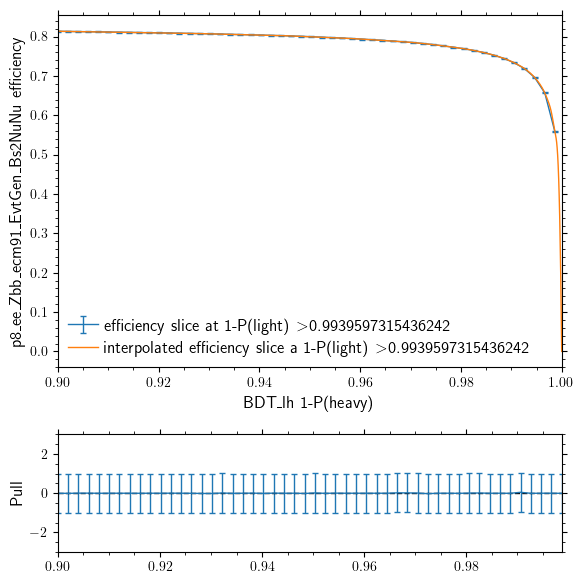

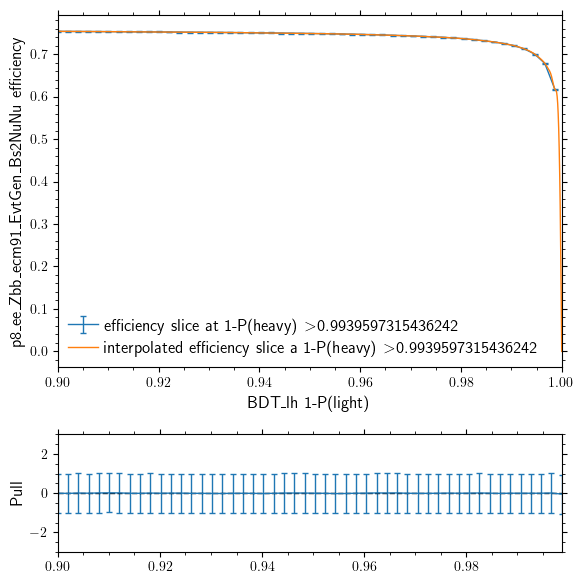

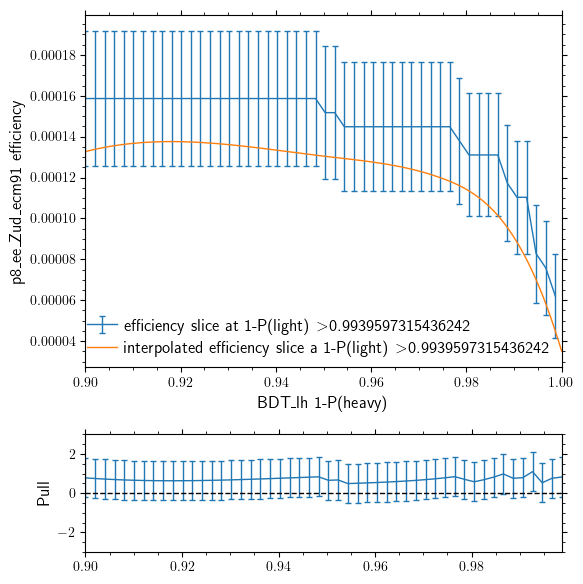

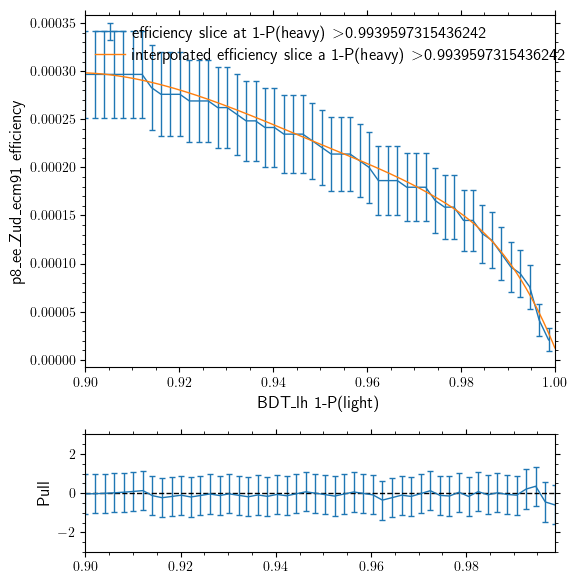

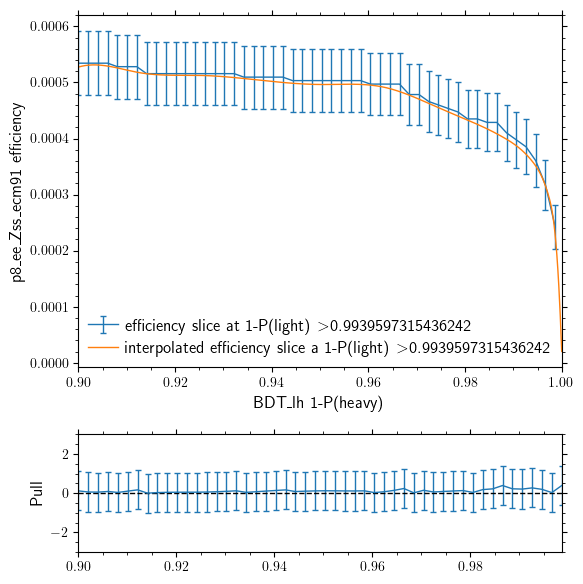

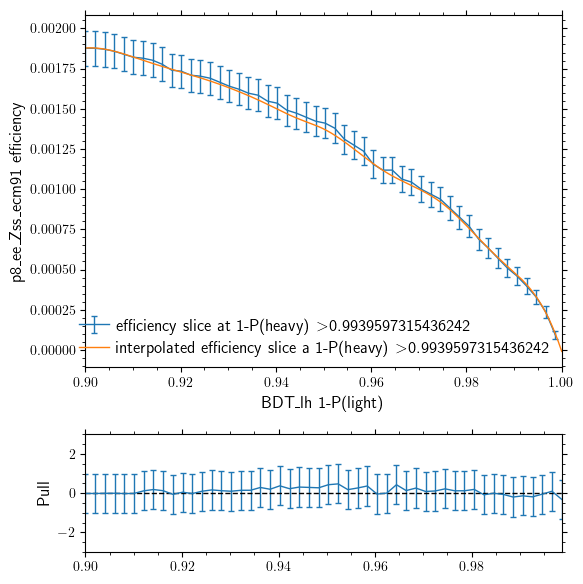

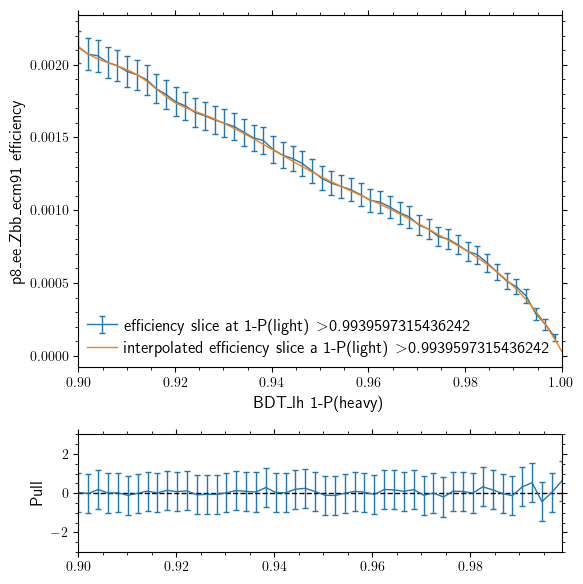

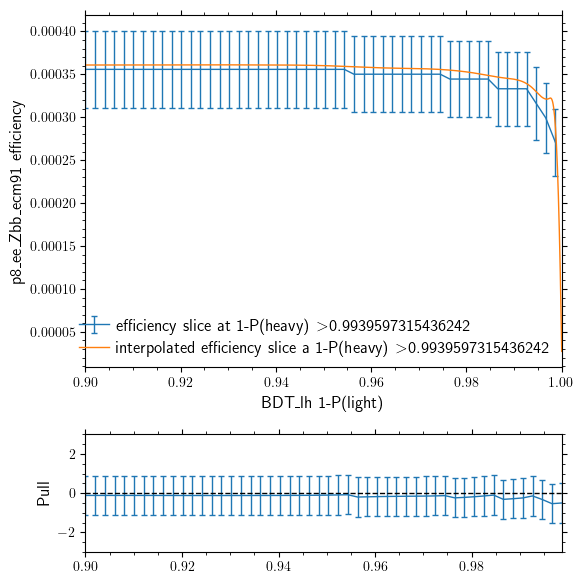

In [15]:
make_eff_plots(mid_eff_dict, mid_interp_eff_dict, mid_N_dict)

## baseline

Calculating S and B


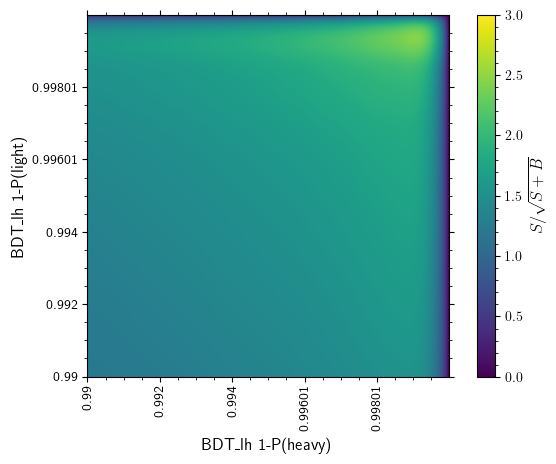

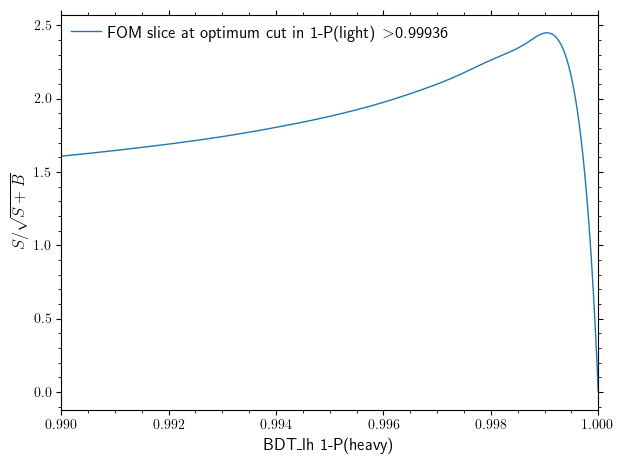

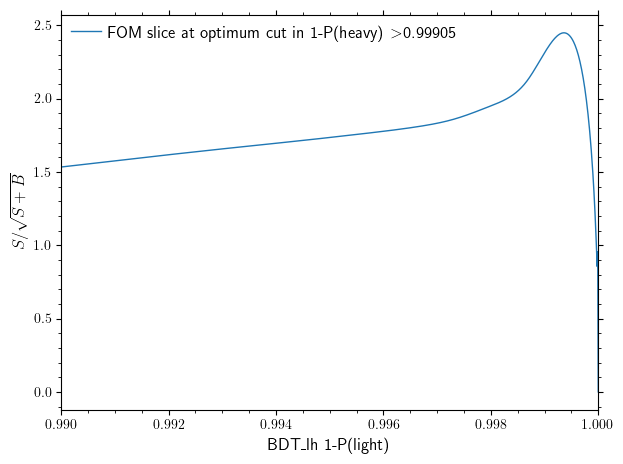

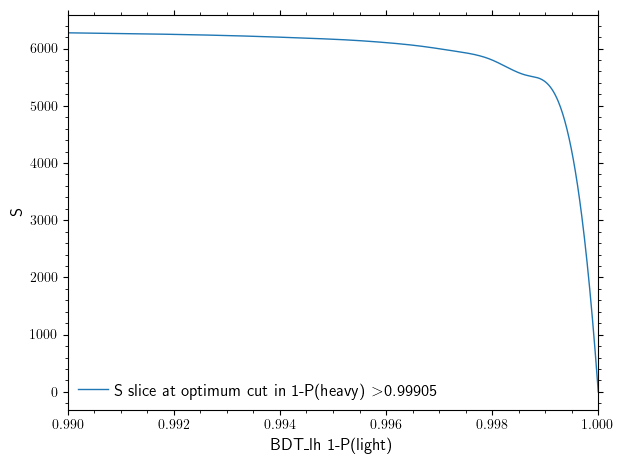

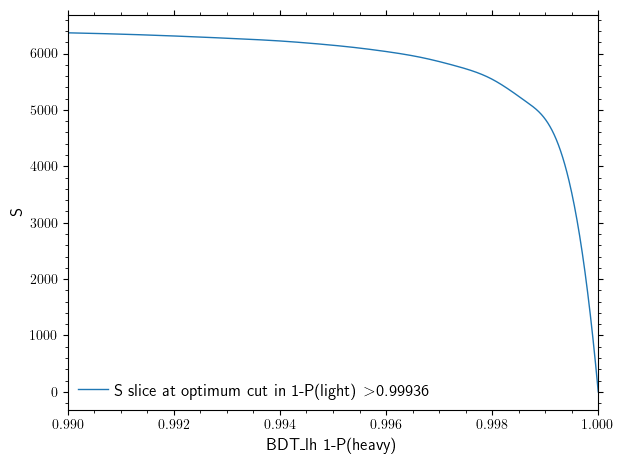

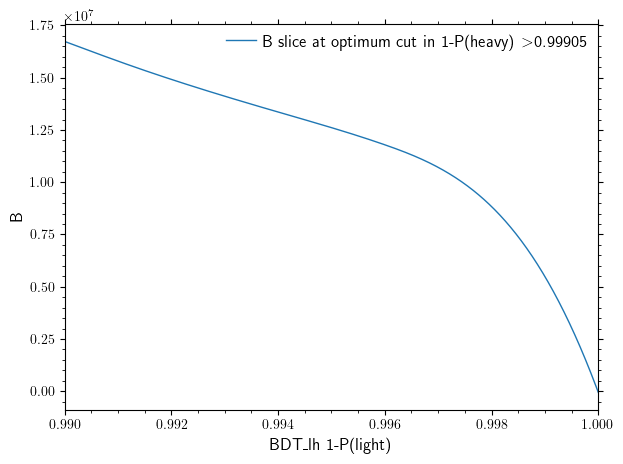

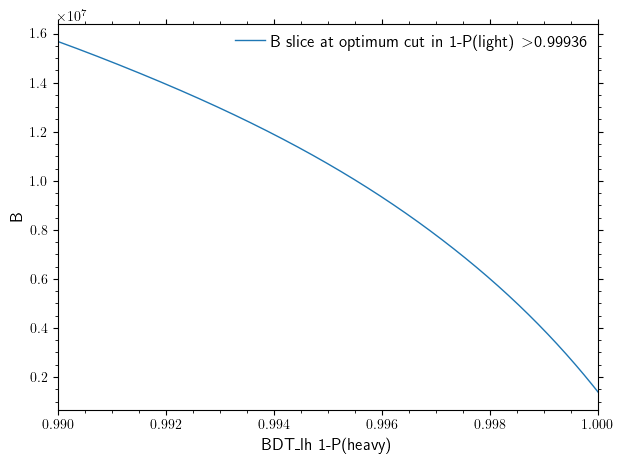

2.4491031021260117
1-P(l)=0.9993593593593594
1-P(h)=0.999049049049049


In [16]:
b_FOM, b_S_arr, b_B_arr, b_B_eff_arr, b_lsearch, b_hsearch, b_sig_BF = run_2d_optimisation(baseline_interp_eff_dict, lrange_plot=(0.99,1) ,hrange_plot=(0.99,1) ,prelim_eff = prelim_cut_eff_dict, sig_BF=1e-7, plot= True,vmax=3)
b_max_sigma =b_FOM.max()
indices = np.unravel_index(np.argmax(b_FOM), np.shape(b_FOM))
l = b_lsearch[indices[0]]
h = b_hsearch[indices[1]]
print(b_max_sigma)
print(f'1-P(l)={l}')
print(f'1-P(h)={h}')

Calculating S and B


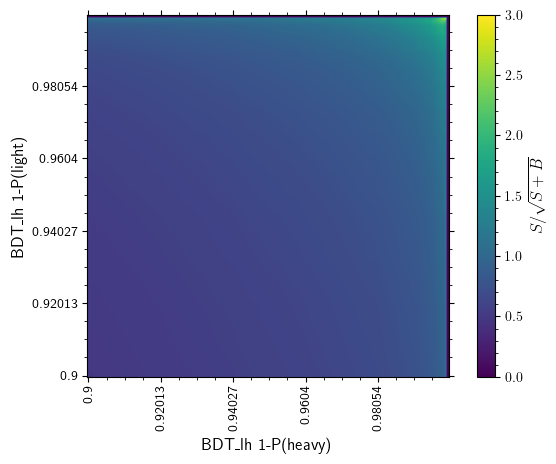

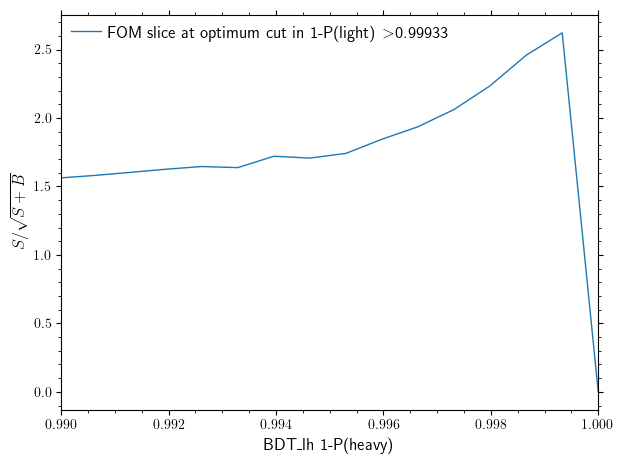

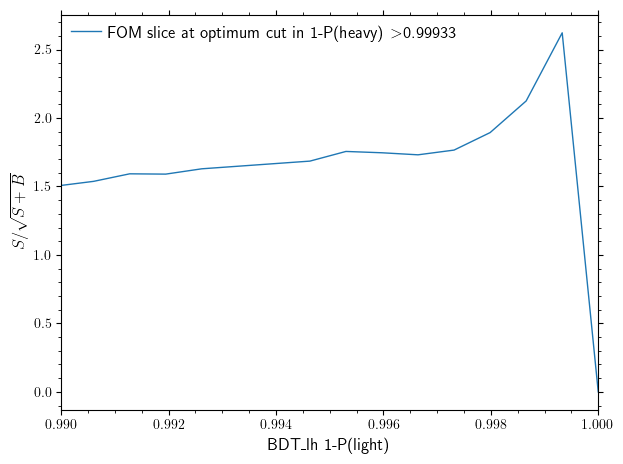

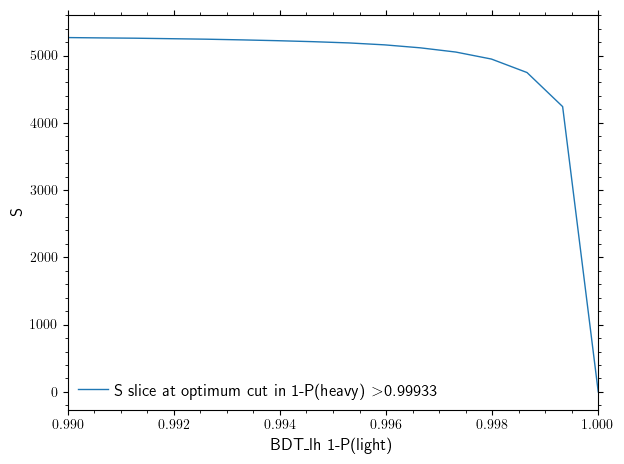

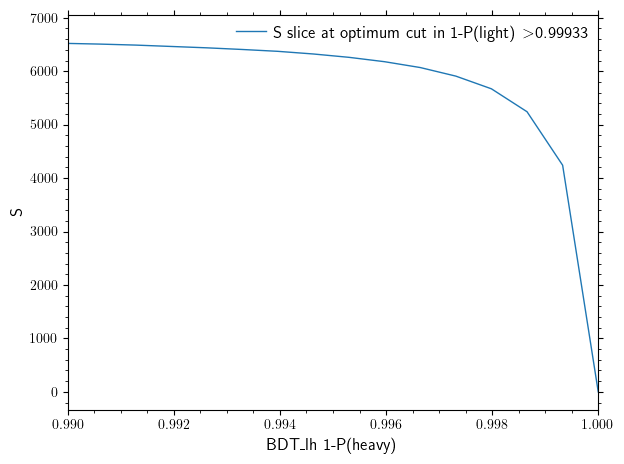

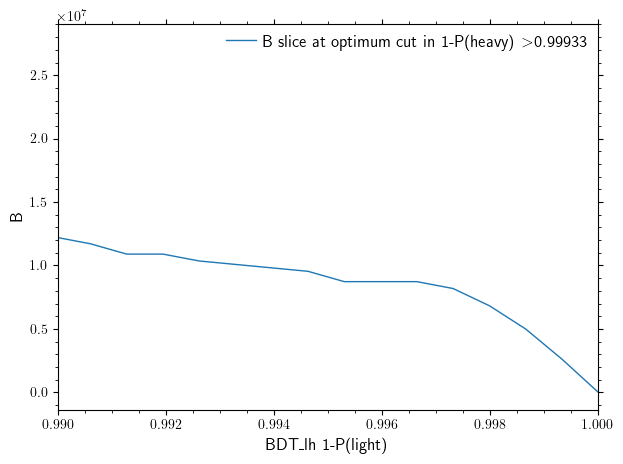

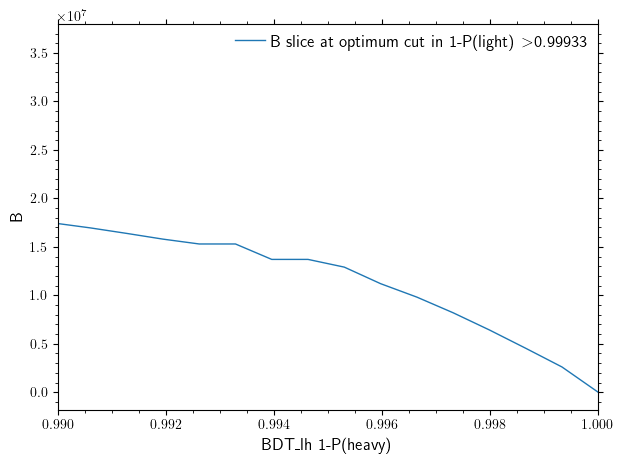

2.622089920091413
1-P(l)=0.9993288590604027
1-P(h)=0.9993288590604027


In [25]:
b_FOM, b_S_arr, b_B_arr, b_B_eff_arr, b_lsearch, b_hsearch, b_sig_BF = run_2d_optimisation_no_interpolation(baseline_eff_dict ,prelim_eff = prelim_cut_eff_dict, sig_BF=1e-7, plot= True,vmax=3)
b_max_sigma =b_FOM.max()
indices = np.unravel_index(np.argmax(b_FOM), np.shape(b_FOM))
l = b_lsearch[indices[0]]
h = b_hsearch[indices[1]]
print(b_max_sigma)
print(f'1-P(l)={l}')
print(f'1-P(h)={h}')

## mid case

Calculating S and B


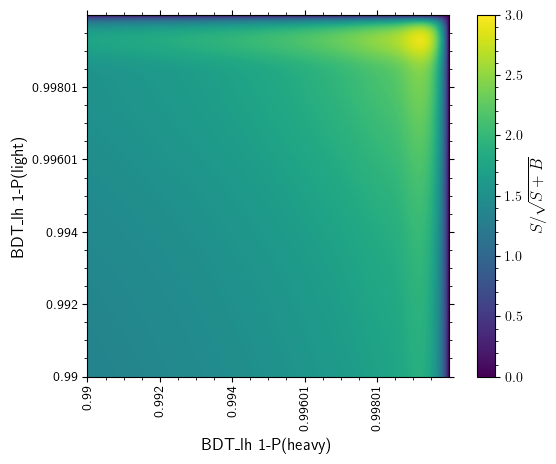

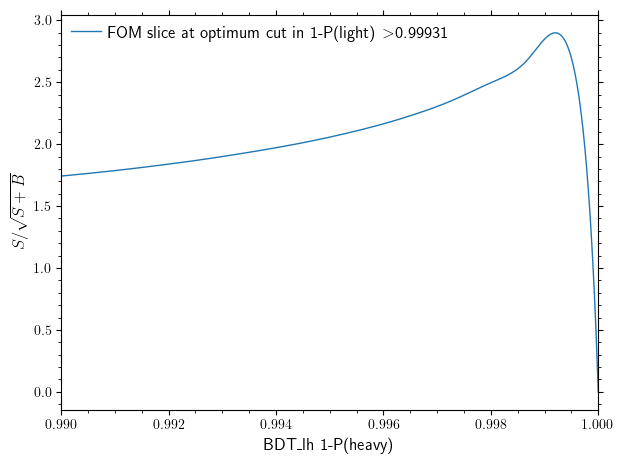

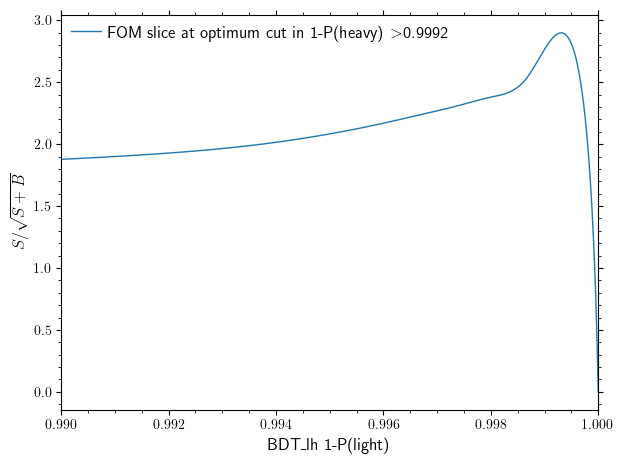

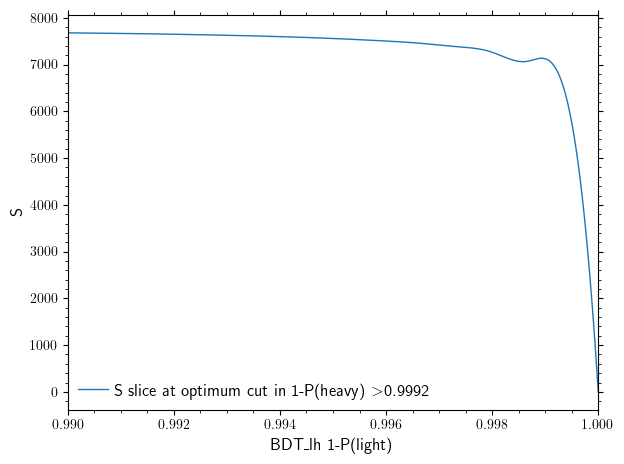

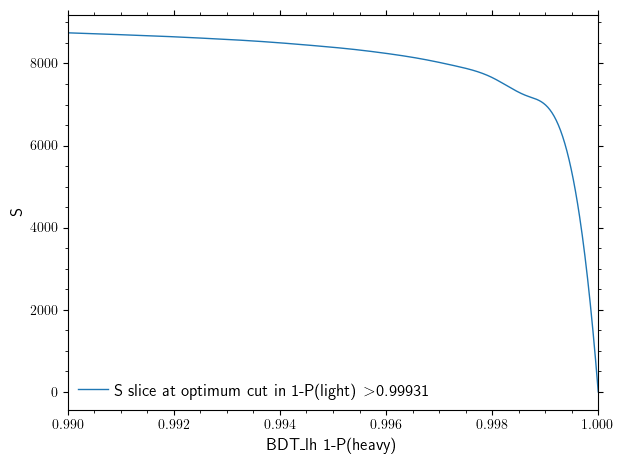

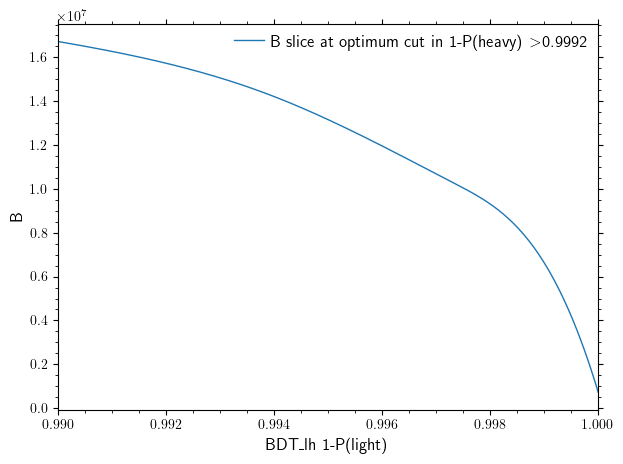

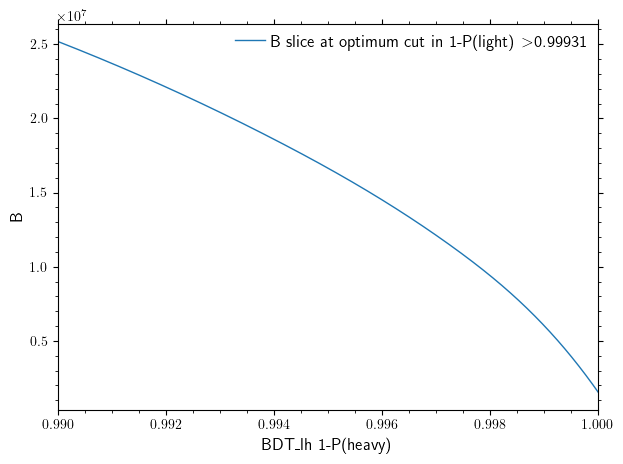

2.8986835916824716
1-P(l)=0.9993093093093093
1-P(h)=0.9991991991991992


In [26]:
FOM, S_arr, B_arr, B_eff_arr, lsearch, hsearch, sig_BF = run_2d_optimisation(mid_interp_eff_dict, lrange_plot=(0.99,1) ,hrange_plot=(0.99,1) ,prelim_eff = prelim_cut_eff_dict, sig_BF=1e-7, plot= True,vmax=3)
max_sigma =FOM.max()
indices = np.unravel_index(np.argmax(FOM), np.shape(FOM))
l = lsearch[indices[0]]
h = hsearch[indices[1]]
print(max_sigma)
print(f'1-P(l)={l}')
print(f'1-P(h)={h}')

## very ot

Calculating S and B


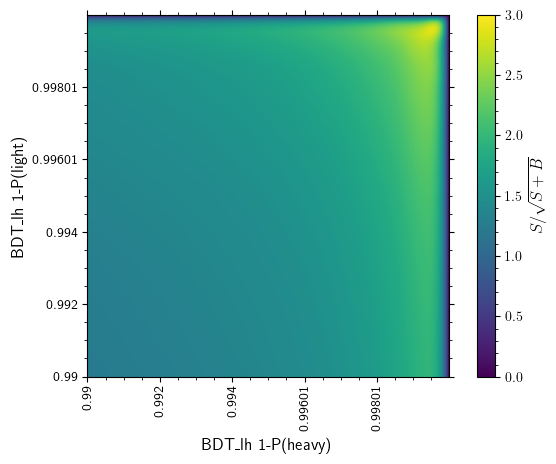

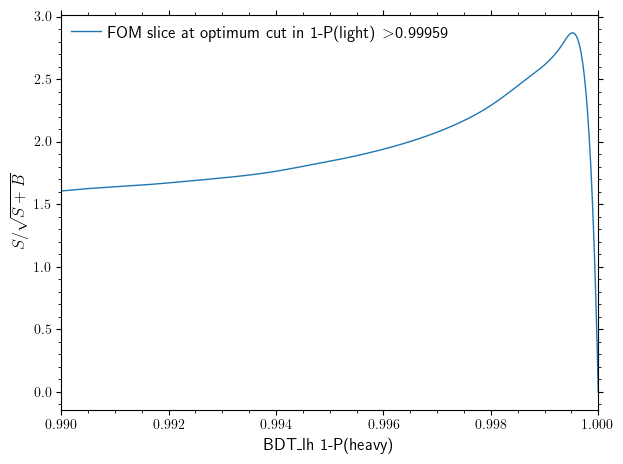

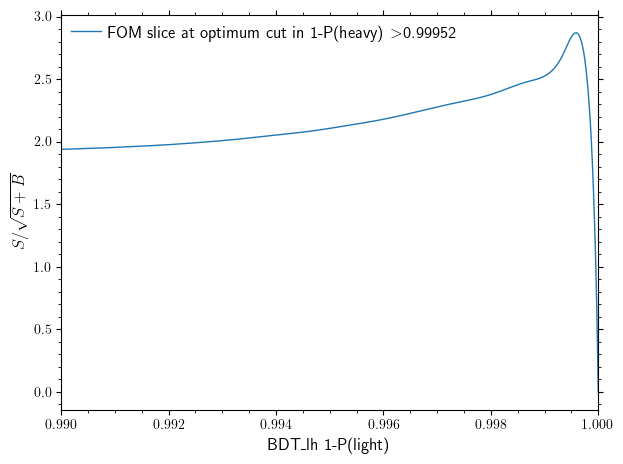

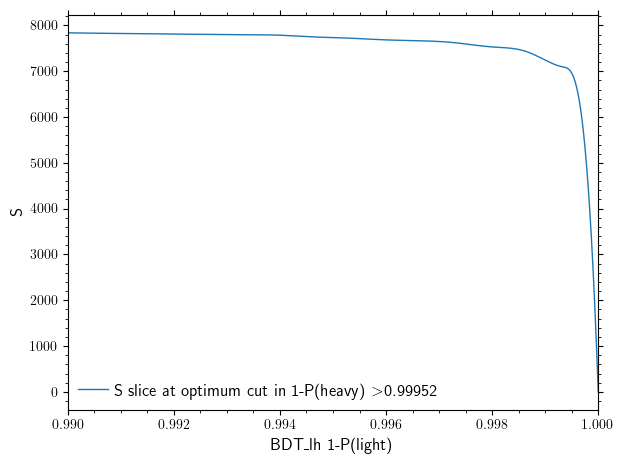

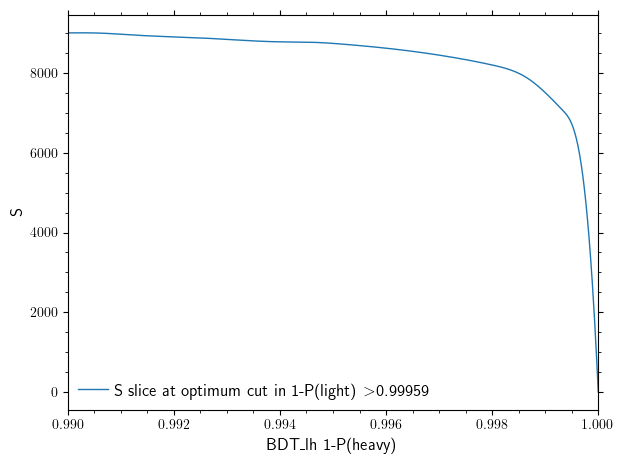

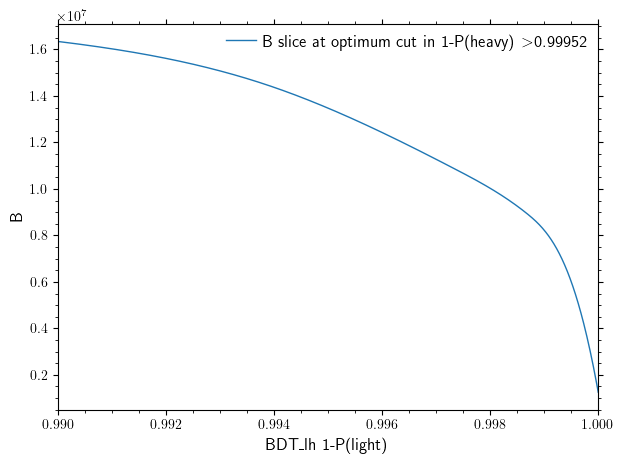

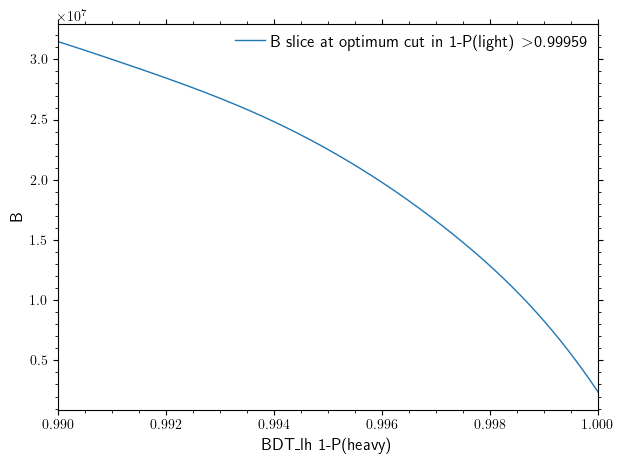

2.8701511367600117
1-P(l)=0.9995895895895895
1-P(h)=0.9995195195195196


In [18]:
ot_FOM, ot_S_arr, ot_B_arr, ot_B_eff_arr, ot_lsearch, ot_hsearch, ot_sig_BF = run_2d_optimisation(ot_interp_eff_dict, lrange_plot=(0.99,1) ,hrange_plot=(0.99,1) ,prelim_eff = prelim_cut_eff_dict, sig_BF=1e-7, plot= True,vmax=3)
ot_max_sigma =ot_FOM.max()
indices = np.unravel_index(np.argmax(ot_FOM), np.shape(ot_FOM))
l = ot_lsearch[indices[0]]
h = ot_hsearch[indices[1]]
print(ot_max_sigma)
print(f'1-P(l)={l}')
print(f'1-P(h)={h}')

## hpp

Calculating S and B


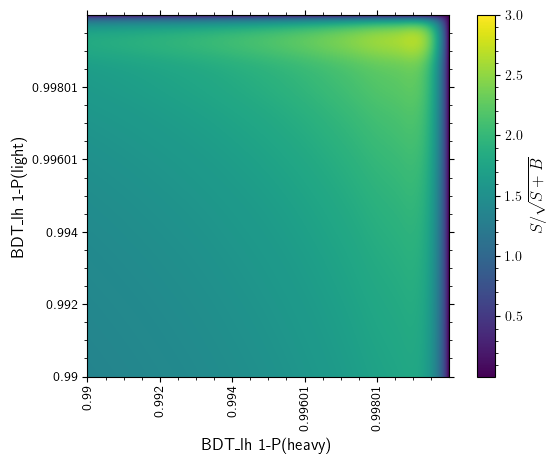

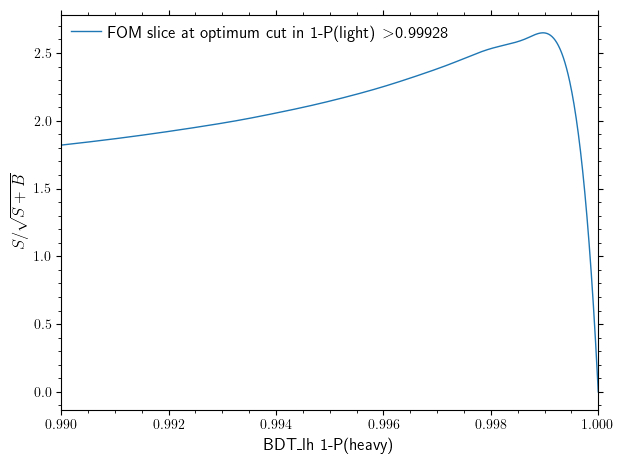

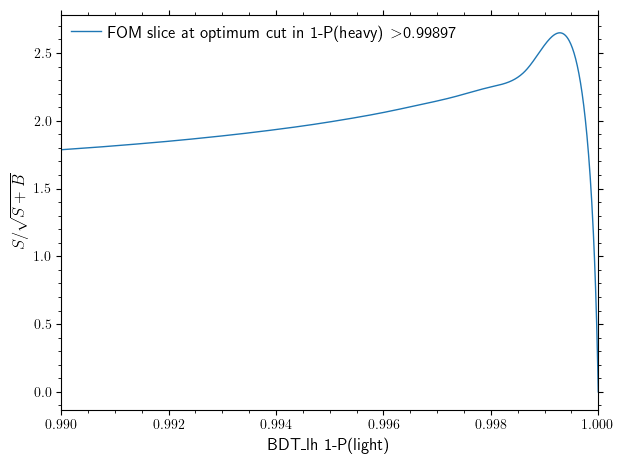

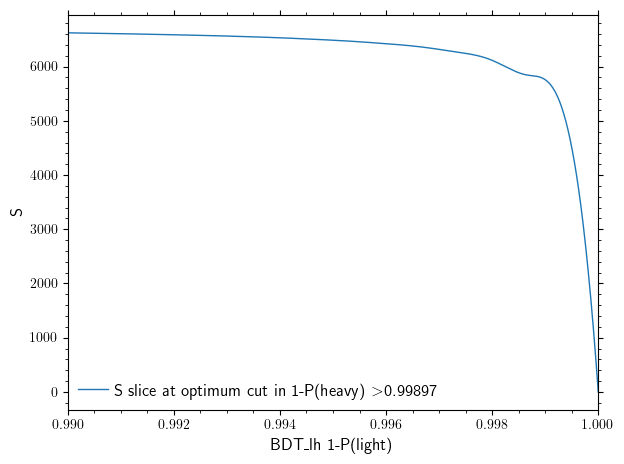

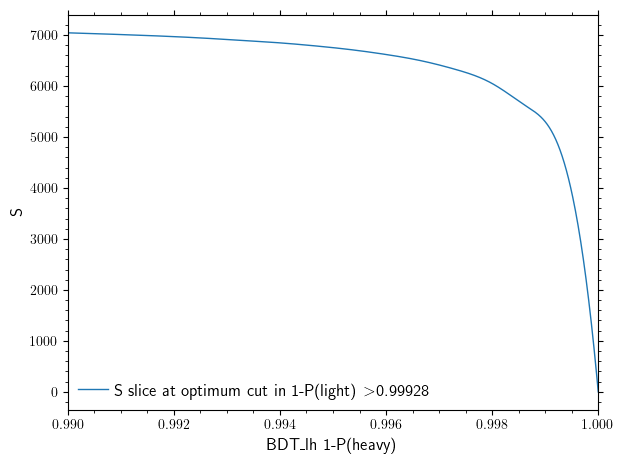

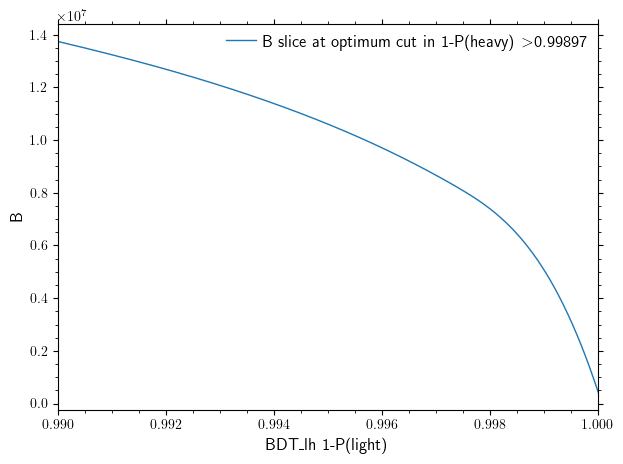

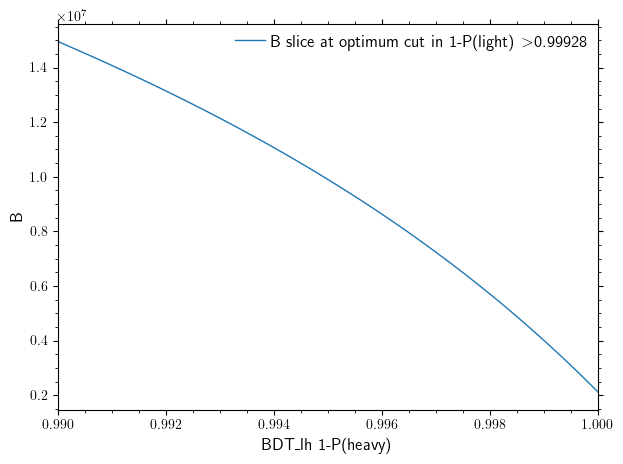

2.648867820639613
1-P(l)=0.9992792792792793
1-P(h)=0.9989689689689689


In [19]:
hpp_FOM, hpp_S_arr, hpp_B_arr, hpp_B_eff_arr, hpp_lsearch, hpp_hsearch, hpp_sig_BF = run_2d_optimisation(hpp_interp_eff_dict, lrange_plot=(0.99,1) ,hrange_plot=(0.99,1) ,prelim_eff = prelim_cut_eff_dict, sig_BF=1e-7, plot= True,vmax=3)
max_sigma =hpp_FOM.max()
indices = np.unravel_index(np.argmax(hpp_FOM), np.shape(hpp_FOM))
l = lsearch[indices[0]]
h = hsearch[indices[1]]
print(max_sigma)
print(f'1-P(l)={l}')
print(f'1-P(h)={h}')

## working on spline

### spline

### curve fit??

Fitted parameters: k = 7.6331, c = 335.1952, A = 0.0035


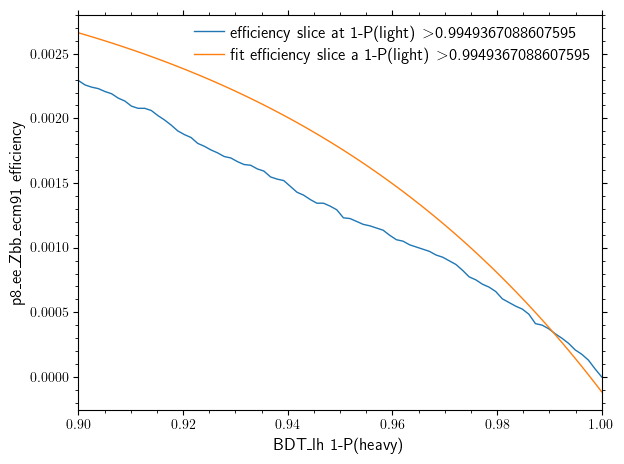

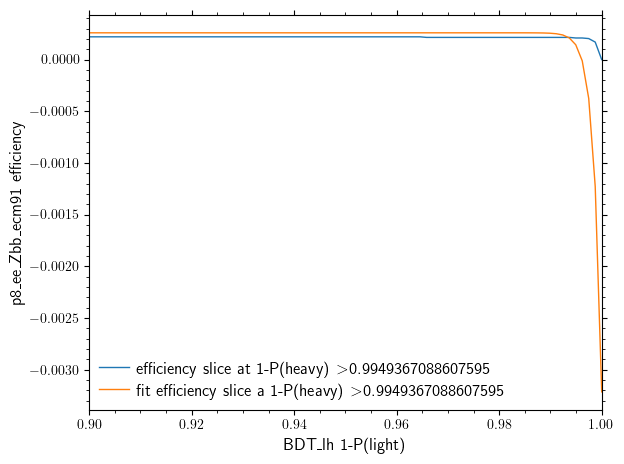

In [92]:
from scipy.optimize import curve_fit

# Generate example data
np.random.seed(42)
lrange=(0.9,1)
hrange=(0.9,1) 
lsearch = np.linspace(*lrange,80) 
hsearch = np.linspace(*hrange,80)

X, Y = np.meshgrid(hsearch, lsearch)

decay = 'p8_ee_Zbb_ecm91'

# Add noise
Z_noisy =  baseline_eff_dict[decay]

# Define function to fit
def model(XY, k, c,A):
    x, y = XY
    #return A*np.log(1 - k * x) + B*np.log(1 - c * y)
    return A*(1-x**(2*k) -y**(2*c)) 

# Flatten data for fitting
x_flat = X.ravel()
y_flat = Y.ravel()
Z_flat = Z_noisy.ravel()

# Initial guess for parameters
initial_guess = [10,10,0.01]

# Bounds: Ensure k, c are positive and <1
bounds = ([0, 0,0], [np.inf, np.inf,1])
# Fit the curve
popt, _ = curve_fit(model, (x_flat, y_flat), Z_flat, p0=initial_guess, bounds=bounds)  
# Bounds ensure k, c are positive and <1

k_fit, c_fit, A_fit = popt

print(f"Fitted parameters: k = {k_fit:.4f}, c = {c_fit:.4f}, A = {A_fit:.4f}")

# Generate fitted surface
Z_fit = model((X, Y), k_fit, c_fit,  A_fit)

# Plot results
n = 75
        
plt.figure()
plt.plot(hsearch,baseline_eff_dict[f"{decay}"][n,:], label=r'efficiency slice at 1-P(light) $>$'+ f'{lsearch[n]}')
plt.plot(hsearch,Z_fit[n,:], label=r'fit efficiency slice a 1-P(light) $>$'+ f'{lsearch[n]}')
plt.xlabel('BDT_lh 1-P(heavy)')
plt.ylabel(f'{decay} efficiency')
plt.legend()
plt.show()

plt.figure()
plt.plot(lsearch,baseline_eff_dict[f"{decay}"][:,n], label=r'efficiency slice at 1-P(heavy) $>$'+ f'{hsearch[n]}')
plt.plot(lsearch,Z_fit[:,n], label=r'fit efficiency slice a 1-P(heavy) $>$'+ f'{hsearch[n]}')
plt.xlabel('BDT_lh 1-P(light)')
plt.ylabel(f'{decay} efficiency')
plt.xlim(0.9,1)
plt.legend()
plt.show()


### trying gaussian filter

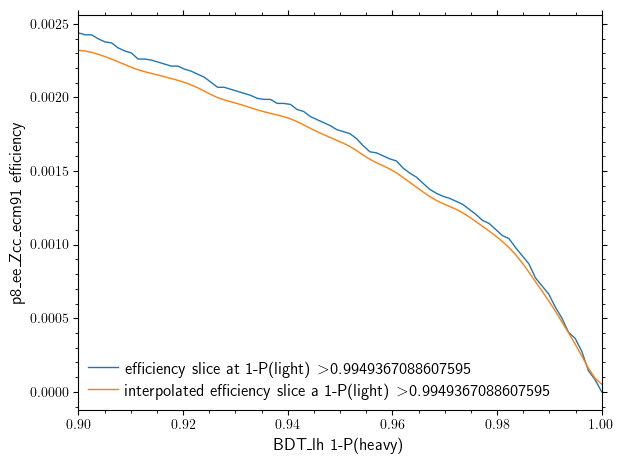

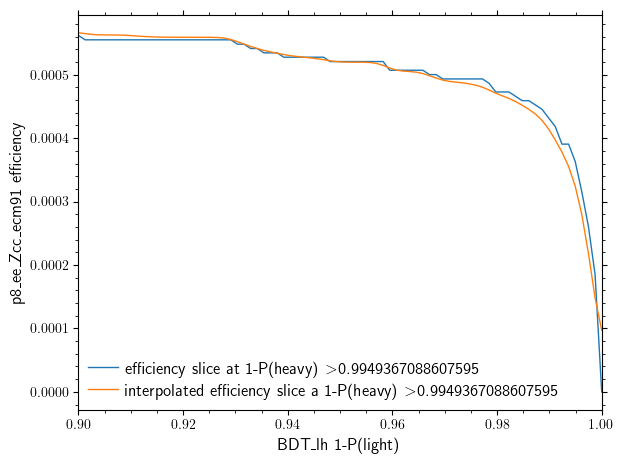

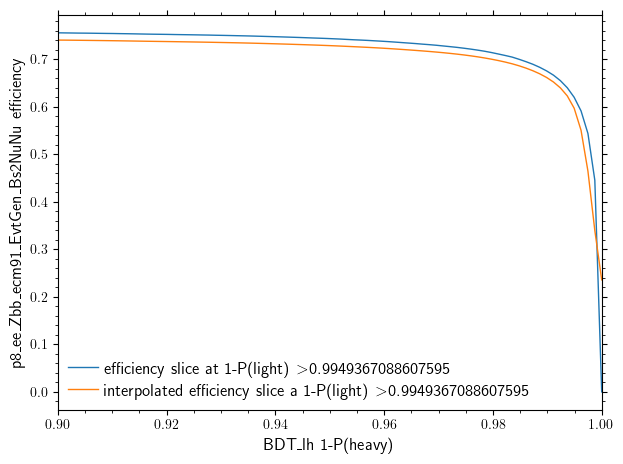

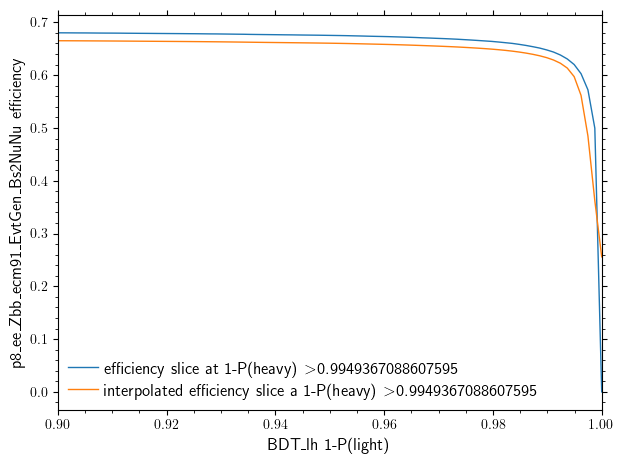

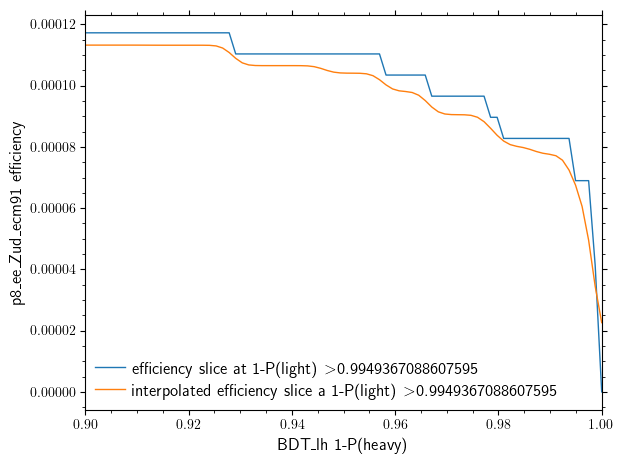

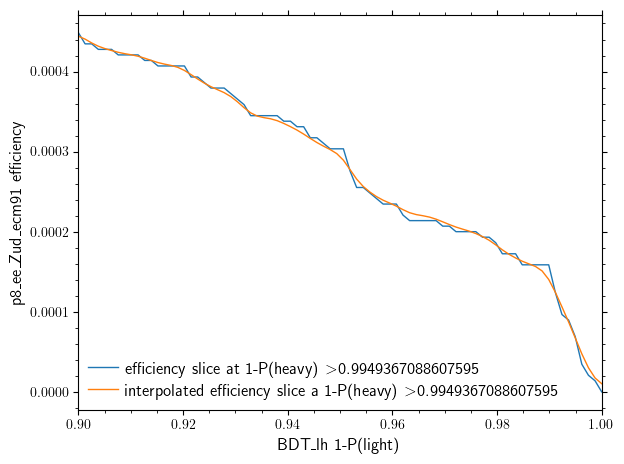

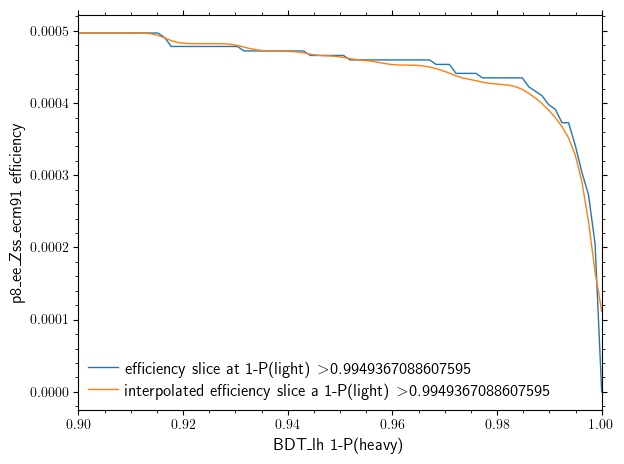

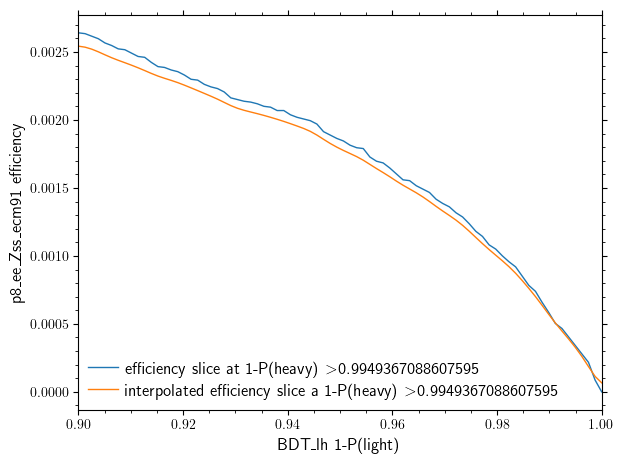

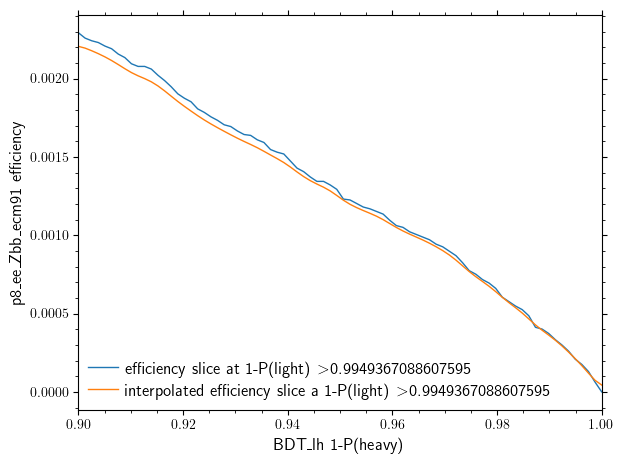

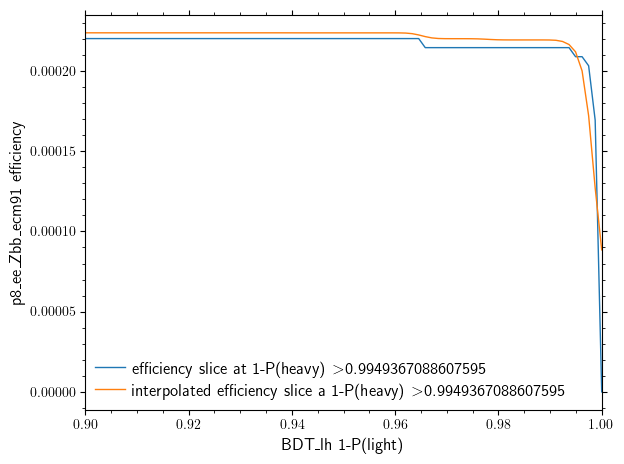

In [28]:
from scipy.ndimage import gaussian_filter

baseline_smoothed_eff_dict={}

# Non-interpolated 2D efficiency dictionary (baseline)
F = baseline_eff_dict

for decay in F.keys():
    eff = baseline_eff_dict[decay]

    # Apply Gaussian smoothing
    eff_smooth = gaussian_filter(eff, sigma=1.4)  # Adjust sigma for more/less smoothing

    baseline_smoothed_eff_dict[decay] = eff_smooth

    lrange=(0.9,1)
    hrange=(0.9,1) 
    lsearch = np.linspace(*lrange,80) 
    hsearch = np.linspace(*hrange,80)
    n = 75
        
    plt.figure()
    plt.plot(hsearch,baseline_eff_dict[f"{decay}"][n,:], label=r'efficiency slice at 1-P(light) $>$'+ f'{lsearch[n]}')
    plt.plot(hsearch,baseline_smoothed_eff_dict[f"{decay}"][n,:], label=r'interpolated efficiency slice a 1-P(light) $>$'+ f'{lsearch[n]}')
    plt.xlabel('BDT_lh 1-P(heavy)')
    plt.ylabel(f'{decay} efficiency')
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(lsearch,baseline_eff_dict[f"{decay}"][:,n], label=r'efficiency slice at 1-P(heavy) $>$'+ f'{hsearch[n]}')
    plt.plot(lsearch,baseline_smoothed_eff_dict[f"{decay}"][:,n], label=r'interpolated efficiency slice a 1-P(heavy) $>$'+ f'{hsearch[n]}')
    plt.xlabel('BDT_lh 1-P(light)')
    plt.ylabel(f'{decay} efficiency')
    plt.legend()
    plt.show()



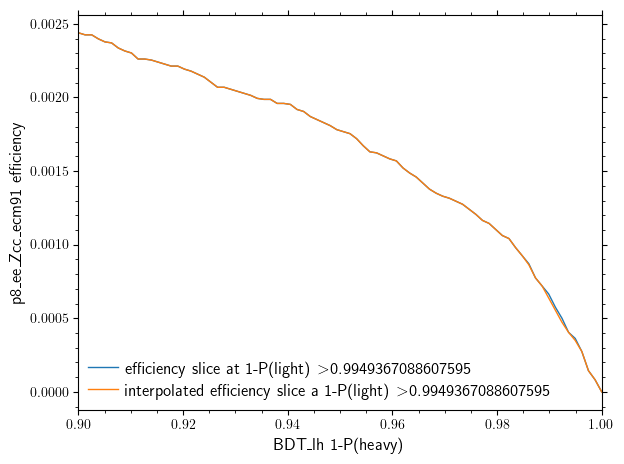

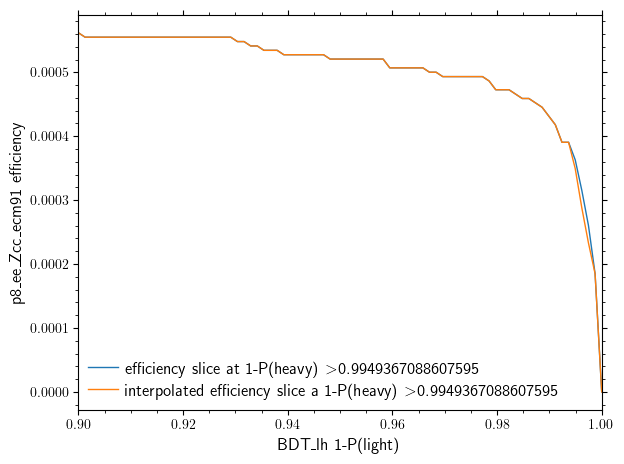

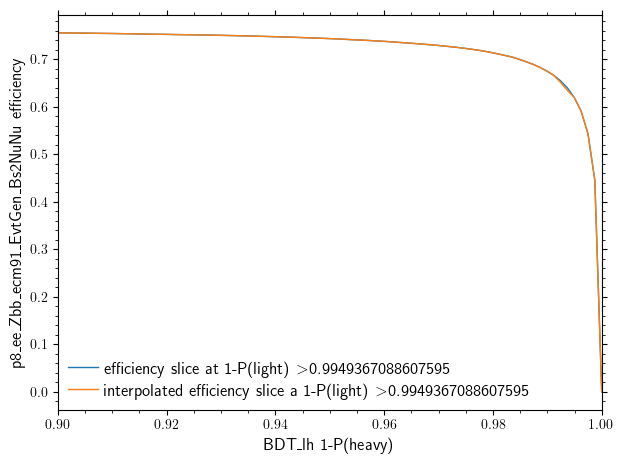

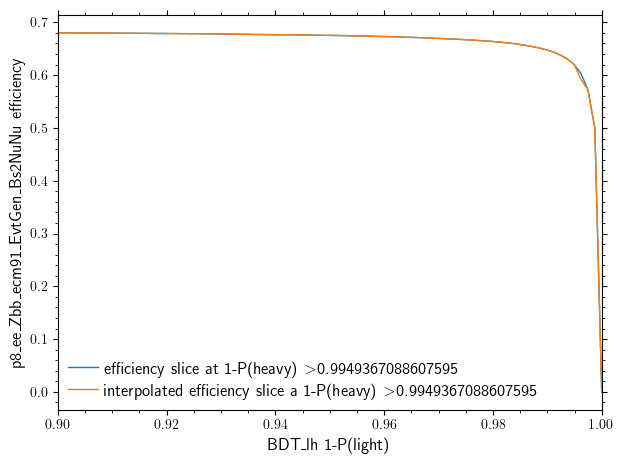

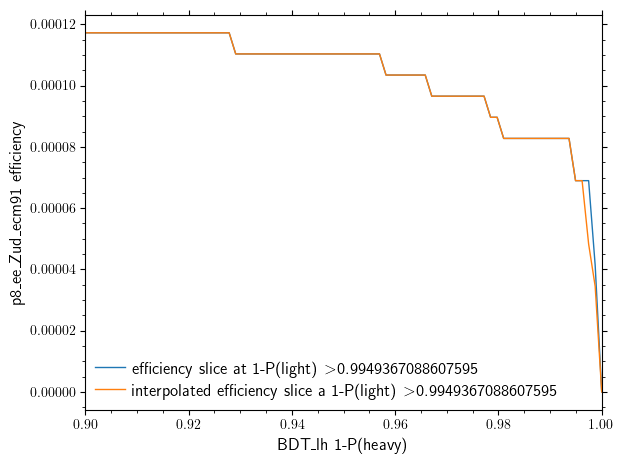

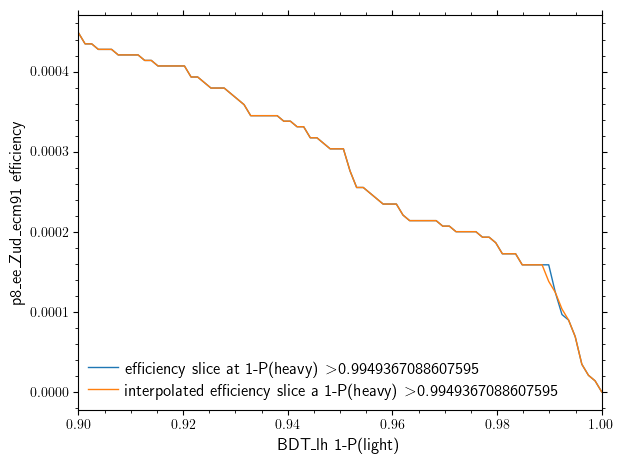

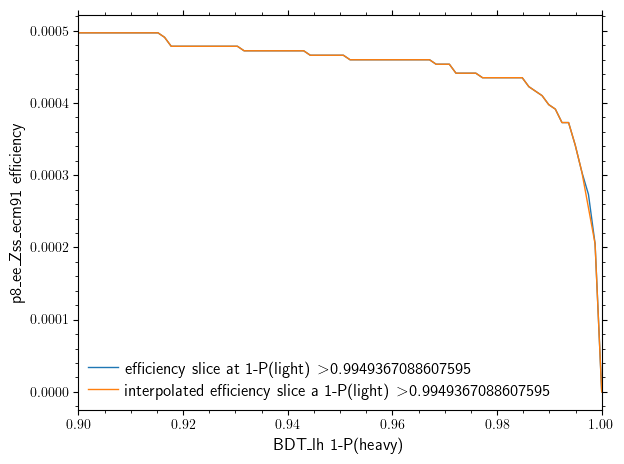

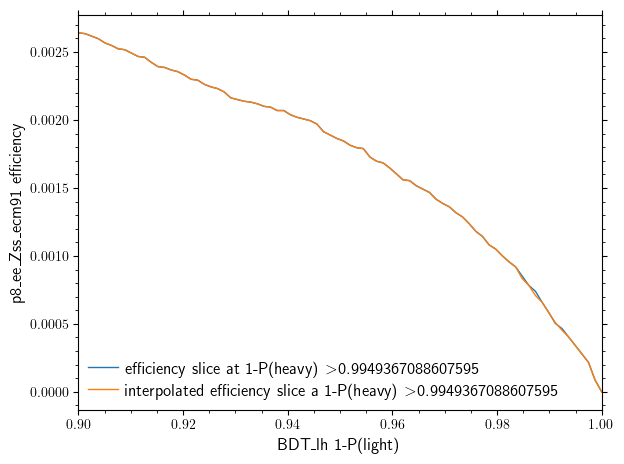

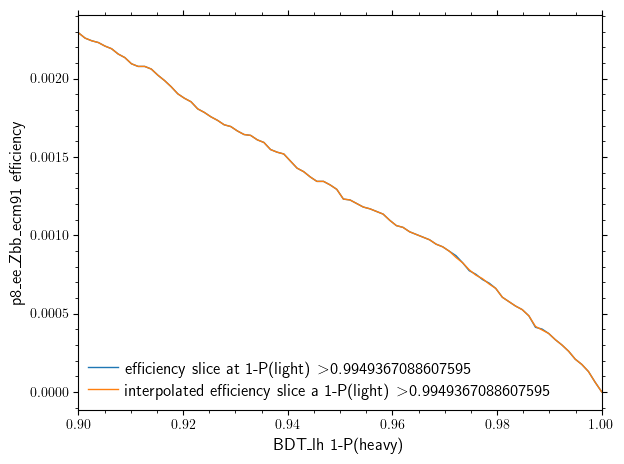

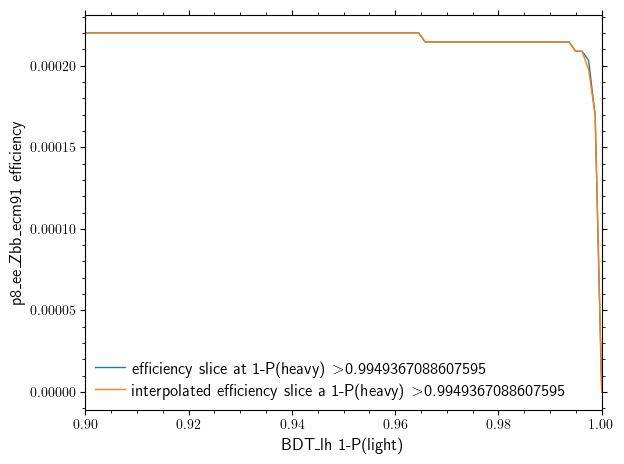

In [26]:
from scipy.ndimage import median_filter


baseline_smoothed_eff_dict={}

# Non-interpolated 2D efficiency dictionary (baseline)
F = baseline_eff_dict

for decay in F.keys():
    eff = baseline_eff_dict[decay]

    # Apply Gaussian smoothing
    eff_smooth = median_filter(eff, size=3)  # Adjust sigma for more/less smoothing

    baseline_smoothed_eff_dict[decay] = eff_smooth

    lrange=(0.9,1)
    hrange=(0.9,1) 
    lsearch = np.linspace(*lrange,80) 
    hsearch = np.linspace(*hrange,80)
    n = 75
        
    plt.figure()
    plt.plot(hsearch,baseline_eff_dict[f"{decay}"][n,:], label=r'efficiency slice at 1-P(light) $>$'+ f'{lsearch[n]}')
    plt.plot(hsearch,baseline_smoothed_eff_dict[f"{decay}"][n,:], label=r'interpolated efficiency slice a 1-P(light) $>$'+ f'{lsearch[n]}')
    plt.xlabel('BDT_lh 1-P(heavy)')
    plt.ylabel(f'{decay} efficiency')
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(lsearch,baseline_eff_dict[f"{decay}"][:,n], label=r'efficiency slice at 1-P(heavy) $>$'+ f'{hsearch[n]}')
    plt.plot(lsearch,baseline_smoothed_eff_dict[f"{decay}"][:,n], label=r'interpolated efficiency slice a 1-P(heavy) $>$'+ f'{hsearch[n]}')
    plt.xlabel('BDT_lh 1-P(light)')
    plt.ylabel(f'{decay} efficiency')
    plt.legend()
    plt.show()


###  no smoothing spline (equivalent to s=0)

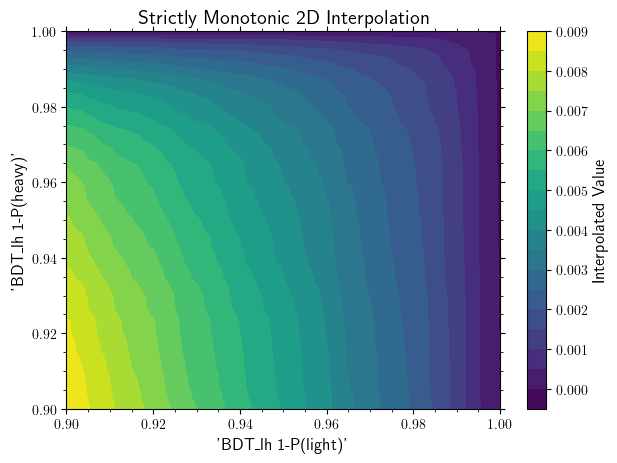

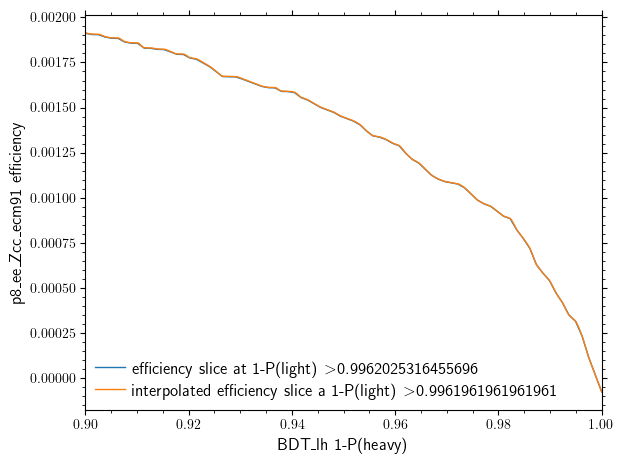

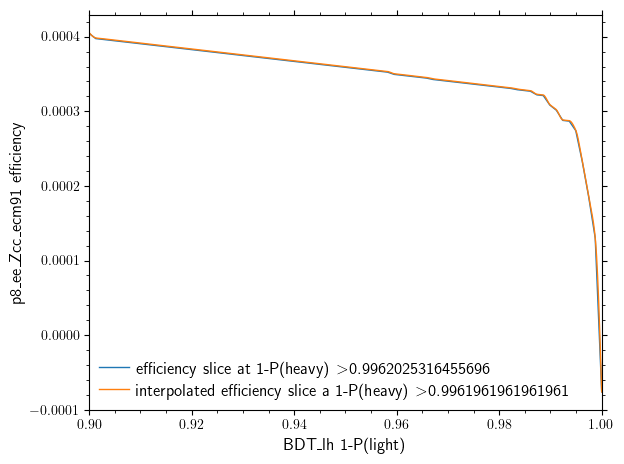

In [33]:

from scipy.interpolate import PchipInterpolator

# Sample 2D monotonic data (falling function)
lsearch = np.linspace(0.9,1,80) 
hsearch = np.linspace(0.9,1,80) 
X, Y = np.meshgrid(lsearch, hsearch)
Z = baseline_eff_dict['p8_ee_Zcc_ecm91']

# Ensure strict monotonicity by adjusting small increases
for i in range(1, Z.shape[0]):
    for j in range(1, Z.shape[1]):
        Z[i, j] = min(Z[i, j], Z[i-1, j] - 1e-6, Z[i, j-1] - 1e-6)

# 1D interpolation along each row (x-direction)
def monotonic_1D_interp(x_vals, y_vals, x_new):
    interp = PchipInterpolator(x_vals, y_vals, axis=0)  # Monotonic along x
    return interp(x_new)

# 2D interpolation using tensor-product approach
x_new = np.linspace(0.9,1,1000)
y_new = np.linspace(0.9,1,1000) 

Z_interp = np.zeros((len(y_new), len(x_new)))

# Interpolate along x first
Z_x_interp = np.array([monotonic_1D_interp(lsearch, Z[i, :], x_new) for i in range(Z.shape[0])])

# Interpolate along y
for j in range(len(x_new)):
    Z_interp[:, j] = monotonic_1D_interp(hsearch, Z_x_interp[:, j], y_new)

# Plot
plt.contourf(x_new, y_new, Z_interp, levels=20, cmap="viridis")
plt.colorbar(label="Interpolated Value")
plt.title("Strictly Monotonic 2D Interpolation")
plt.xlabel("'BDT_lh 1-P(light)'")
plt.ylabel("'BDT_lh 1-P(heavy)'")
plt.show()




lsearchinterp = np.linspace(0.9,1,1000) 
hsearchinterp = np.linspace(0.9,1,1000)
decay = 'p8_ee_Zcc_ecm91'
plt.figure()
plt.plot(hsearch,baseline_eff_dict['p8_ee_Zcc_ecm91'][76,:], label=r'efficiency slice at 1-P(light) $>$'+ f'{lsearch[76]}')
plt.plot(hsearchinterp,Z_interp[961,:], label=r'interpolated efficiency slice a 1-P(light) $>$'+ f'{x_new[961]}')
plt.xlabel('BDT_lh 1-P(heavy)')
plt.ylabel(f'{decay} efficiency')
plt.legend()
plt.show()

plt.figure()
plt.plot(lsearch,baseline_eff_dict['p8_ee_Zcc_ecm91'][:,76], label=r'efficiency slice at 1-P(heavy) $>$'+ f'{hsearch[76]}')
plt.plot(lsearchinterp,Z_interp[:,961], label=r'interpolated efficiency slice a 1-P(heavy) $>$'+ f'{y_new[961]}')
plt.xlabel('BDT_lh 1-P(light)')
plt.ylabel(f'{decay} efficiency')
plt.legend()
plt.show()
